In [1]:
# !unzip -o -q ./data/deepseek-new.zip -d ./data/

## Dependencies

In [1]:
import pandas as pd
import numpy as np

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from icecream import ic

import os

## Data Preparing

In [2]:
df_labled = pd.read_csv('./data/train.csv')
df_test = pd.read_csv('./data/test.csv')
df_labled.head()

,id,label
0,44263a6b,Scyther
1,9b6344f2,Butterfree
2,c89ffbde,Rhydon
3,95bbd7ff,Koffing
4,c3e8a9e1,Dewgong


In [3]:
df_test.head()

,id
0,9553b359
1,c6bcf2c2
2,5493d25f
3,f17f13b5
4,bb4e5386


### EDA

In [4]:
df_labled.shape

(5243, 2)

In [5]:
df_labled['label'].nunique()

150

<Axes: xlabel='label', ylabel='Count'>

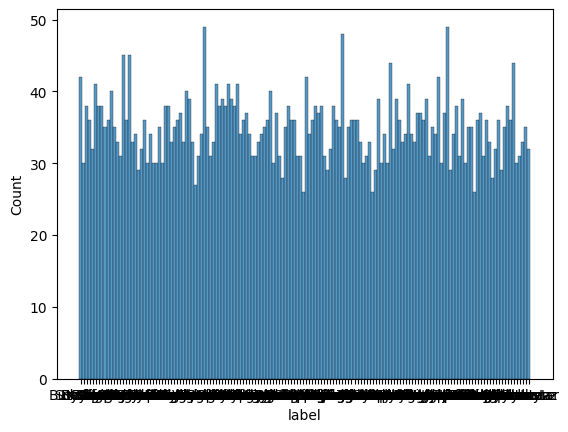

In [6]:
sns.histplot(df_labled, x='label')

In [7]:
df_train, df_val = train_test_split(df_labled, test_size=0.3, stratify=df_labled['label'], shuffle=True, random_state=42)
df_train.shape, df_val.shape

((3670, 2), (1573, 2))

<Axes: xlabel='label', ylabel='count'>

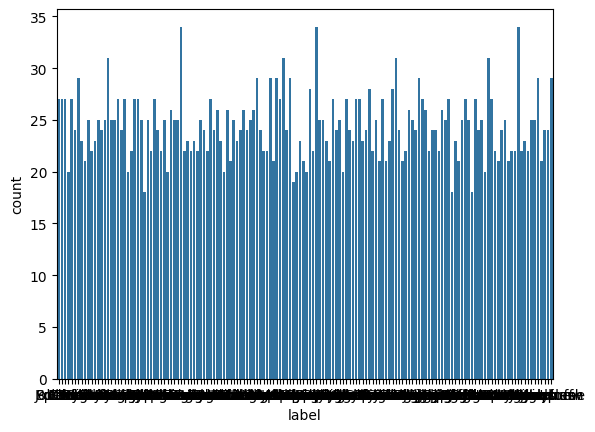

In [8]:
sns.countplot(data=df_train, x='label')

<Axes: xlabel='label', ylabel='count'>

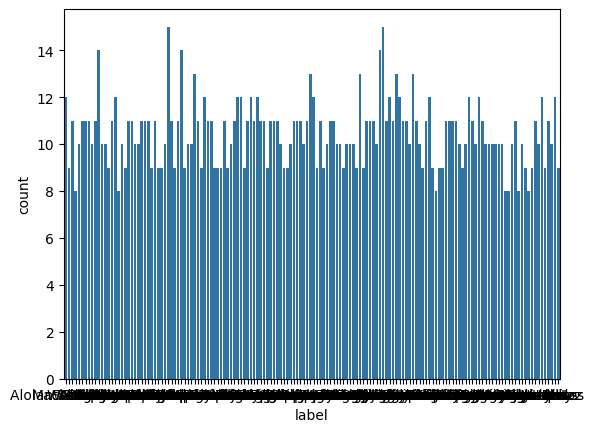

In [9]:
sns.countplot(data=df_val, x='label')

In [10]:
label_encoder = LabelEncoder()
label_encoder.fit(df_labled['label'])

LabelEncoder()

In [11]:
label_encoder.inverse_transform([0])

array(['Abra'], dtype=object)

In [12]:
label_encoder.transform(['Abra'])

array([0])

### Custom Dataset & Transforms

In [13]:
class PockemonDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_path: str, transform: transforms.Compose = None, is_test = False):
        super().__init__()

        self.df = df
        self.img_path = img_path
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, index):
        id = self.df.iloc[index]['id']
        label = 0
        if not self.is_test:
            label = self.df.iloc[index]['label']
            label = label_encoder.transform([label])[0]

        img_path = os.path.join(self.img_path, f"{id}.jpg")
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return (img, label)

In [14]:
IN_SHAPE = (128, 128)

train_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(IN_SHAPE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

### DataLoaders

In [15]:
train_dataset = PockemonDataset(df_train, "./data/train", train_transforms)
val_dataset = PockemonDataset(df_val, "./data/train", test_transforms)
test_dataset = PockemonDataset(df_test, "./data/test", test_transforms, is_test=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4308496].


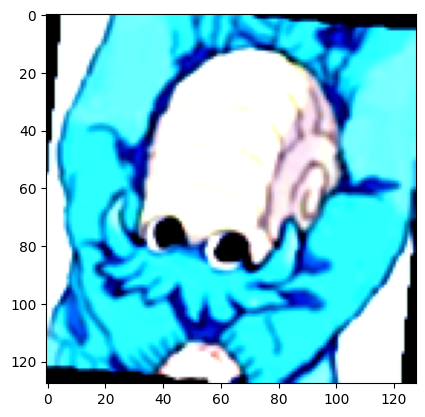

In [16]:
img_idx = np.random.randint(0, len(train_dataset))
img = train_dataset[img_idx][0].numpy()
img = np.transpose(img, (1, 2, 0))

plt.imshow(img)

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, persistent_workers=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

## Training

### Train Loop

In [18]:
def train_loop(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        optimizer: torch.optim.AdamW,
        criterion = nn.CrossEntropyLoss(),
        num_epoches = 100,
        model_name = "best_model.pth"
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metrics = []

    for epoch in trange(num_epoches):
        model.train()
        cur_train_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)

            optimizer.zero_grad()
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            cur_train_loss += loss.item()
        
        train_losses.append(cur_train_loss / len(train_loader))
        
        model.eval()
        cur_val_loss = 0.
        cur_preds = []
        val_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)

                loss = criterion(y_pred, y_batch)
                cur_val_loss += loss.item()

                y_pred = y_pred.detach().cpu().numpy()
                y_pred = np.argmax(y_pred, axis=1)
                y_batch = y_batch.cpu().numpy()

                val_labels.extend(y_batch)
                cur_preds.extend(y_pred)

        val_losses.append(cur_val_loss / len(val_loader))
        cur_metric = f1_score(val_labels, cur_preds, average='macro')
        if len(val_metrics) < 2 or cur_metric > max(val_metrics):
            torch.save(model.state_dict(), f"./models/{model_name}")
            print("!!! NEW BEST MODEL !!!")
        val_metrics.append(cur_metric)

        print(f"Epoch {epoch}: train_loss {train_losses[-1]}, val_loss {val_losses[-1]}, val_f1 {cur_metric}")
        
        if epoch % 10 == 0 or epoch == num_epoches - 1:
            if epoch == 0:
                continue
            
            fig, axs = plt.subplots(1, 2, figsize=(10, 4))

            axs[0].set_title("Losses")
            axs[0].plot(train_losses, label='Train')
            axs[0].plot(val_losses, label='Val')
            axs[0].legend()
            axs[0].grid(True)

            axs[1].set_title("val F1-score")
            axs[1].plot(val_metrics)
            axs[1].grid(True)

            plt.tight_layout()
            plt.show()

    print(f"Best score: {max(val_metrics)}")

    return model


### Model

In [20]:
class PockemonModel(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            out_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(PockemonModel, self).__init__()

        self.img_shape = img_shape
        self.in_ch = in_ch

        conv_layers = [
            nn.Conv2d(in_ch, hidden_ch[0], 3, 1, 1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU(),
            nn.Conv2d(hidden_ch[0], hidden_ch[0], 3, 1, 1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(conv_dropout)
        ]
        last_ch = hidden_ch[0]
        for ch in hidden_ch[1:]:
            conv_layers.extend([
                nn.Conv2d(last_ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Conv2d(ch, ch, 3, padding=1),
                nn.BatchNorm2d(ch),
                nn.ReLU(),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(conv_dropout)
            ])
            last_ch = ch

        self.conv_net = nn.Sequential(*conv_layers)
        
        fc_layers = []
        last_dim = self._shape_after_conv(self.conv_net)
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout1d(fc_dropout)
            ])
            last_dim = dim
        fc_layers.extend([
            nn.Linear(last_dim, out_dim)
        ])

        self.fc_net = nn.Sequential(*fc_layers)
        
    def forward(self, x):
        x = self.conv_net(x)
        flatten = nn.Flatten()
        x = flatten(x)
        x = self.fc_net(x)
        return x


    def _shape_after_conv(self, conv_block: nn.Module):
        A = torch.zeros(size=(1, self.in_ch, *self.img_shape))
        A = conv_block(A)
        flatten = nn.Flatten()
        A = flatten(A)
        return A.shape[1]
        


ic| PockemonModel(
        img_shape=IN_SHAPE,
        in_ch=3,
        hidden_ch=[32, 64, 128, 256],
        hidden_fc=[256],
        out_dim=150,
        conv_dropout=0.1
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (5): ReLU()
           (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (7): Dropout2d(p=0.1, inplace=False)
           (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (10): ReLU()
           (11): MaxPool2d(ker

!!! NEW BEST MODEL !!!
Epoch 0: train_loss 4.989730999387544, val_loss 4.6172278844393215, val_f1 0.01916034668516482


  1%|          | 2/200 [00:05<08:09,  2.47s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 4.599639448626288, val_loss 4.246910572052002, val_f1 0.026524073590409522


  2%|▏         | 3/200 [00:07<07:49,  2.39s/it]

!!! NEW BEST MODEL !!!
Epoch 2: train_loss 4.308275765386121, val_loss 3.8613595228928785, val_f1 0.06528871545013537


  2%|▏         | 4/200 [00:09<07:39,  2.34s/it]

!!! NEW BEST MODEL !!!
Epoch 3: train_loss 4.072361049980953, val_loss 3.6316448541787953, val_f1 0.10695072322903892


  2%|▎         | 5/200 [00:11<07:31,  2.31s/it]

!!! NEW BEST MODEL !!!
Epoch 4: train_loss 3.879347538125926, val_loss 3.360882428976206, val_f1 0.15767409357910858


  3%|▎         | 6/200 [00:14<07:25,  2.30s/it]

!!! NEW BEST MODEL !!!
Epoch 5: train_loss 3.7566703352434883, val_loss 3.1632454028496375, val_f1 0.21642790956296049


  4%|▎         | 7/200 [00:16<07:21,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 6: train_loss 3.5417607652729957, val_loss 2.94759464263916, val_f1 0.25550181110701314


  4%|▍         | 8/200 [00:18<07:18,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 7: train_loss 3.4259860597807785, val_loss 2.862865136219905, val_f1 0.2628351756664989


  4%|▍         | 9/200 [00:20<07:15,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 8: train_loss 3.296261557217302, val_loss 2.749679216971764, val_f1 0.2893358873569746


  5%|▌         | 10/200 [00:23<07:13,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 3.205523466241771, val_loss 2.5786006450653076, val_f1 0.34800130719140915
!!! NEW BEST MODEL !!!
Epoch 10: train_loss 3.103555342246746, val_loss 2.4503337419950046, val_f1 0.37894211097846764


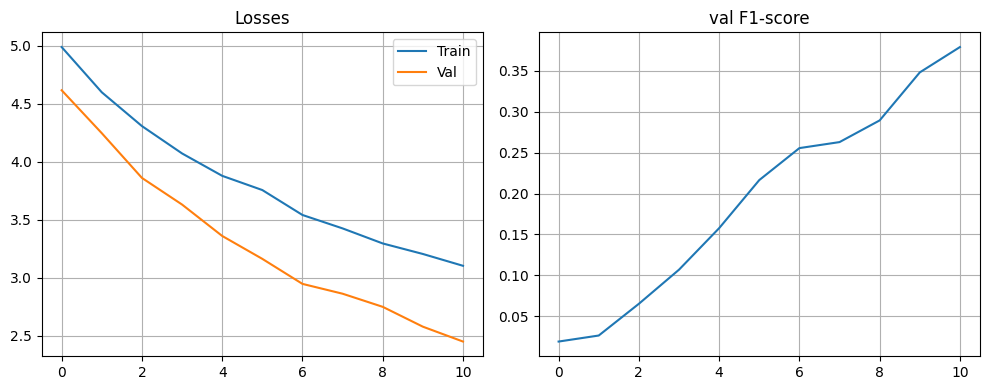

  6%|▌         | 12/200 [00:27<07:13,  2.31s/it]

!!! NEW BEST MODEL !!!
Epoch 11: train_loss 3.0250372557804504, val_loss 2.3674481832064114, val_f1 0.43143948339965144


  6%|▋         | 13/200 [00:30<07:08,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 2.8380197738779, val_loss 2.23501023879418, val_f1 0.4470899927625559


  7%|▋         | 14/200 [00:32<07:04,  2.28s/it]

Epoch 13: train_loss 2.8556320338413634, val_loss 2.263885259628296, val_f1 0.42447042197912954


  8%|▊         | 15/200 [00:34<07:00,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 14: train_loss 2.7076579126818427, val_loss 2.10388550391564, val_f1 0.4739771462478624


  8%|▊         | 16/200 [00:36<06:57,  2.27s/it]

Epoch 15: train_loss 2.7007294276664995, val_loss 2.1140560186826267, val_f1 0.46819373985838336


  8%|▊         | 17/200 [00:39<06:55,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 16: train_loss 2.58737222901706, val_loss 1.9950607831661518, val_f1 0.4840599575230799


  9%|▉         | 18/200 [00:41<06:52,  2.27s/it]

Epoch 17: train_loss 2.5338331584272713, val_loss 1.9666754649235652, val_f1 0.48294661840711245


 10%|▉         | 19/200 [00:43<06:50,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 18: train_loss 2.490346851020024, val_loss 1.8922315194056585, val_f1 0.540742642955728


 10%|█         | 20/200 [00:45<06:48,  2.27s/it]

Epoch 19: train_loss 2.4742201484482864, val_loss 1.844817464168255, val_f1 0.5295513413155942
!!! NEW BEST MODEL !!!
Epoch 20: train_loss 2.4036609879855453, val_loss 1.7846227058997521, val_f1 0.5477336892915255


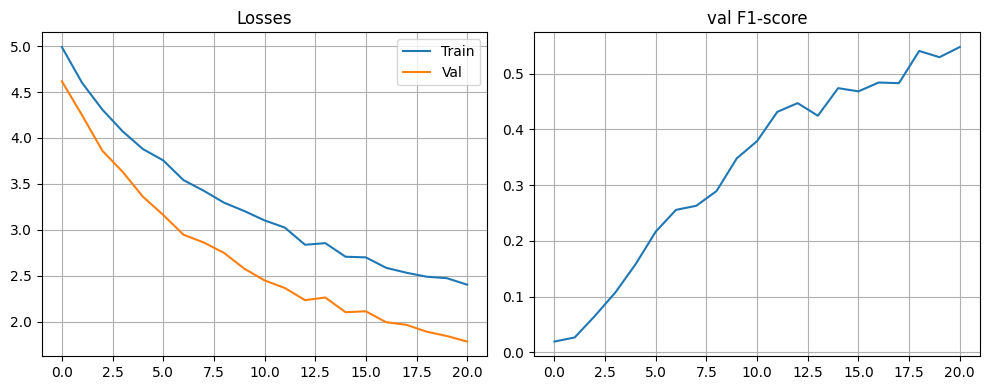

 11%|█         | 22/200 [00:50<06:49,  2.30s/it]

!!! NEW BEST MODEL !!!
Epoch 21: train_loss 2.297991452545955, val_loss 1.7007689017515917, val_f1 0.5636289095648628


 12%|█▏        | 23/200 [00:52<06:46,  2.30s/it]

!!! NEW BEST MODEL !!!
Epoch 22: train_loss 2.3301380996046395, val_loss 1.6923581911967351, val_f1 0.582277888327582


 12%|█▏        | 24/200 [00:55<06:42,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 23: train_loss 2.272759667758284, val_loss 1.6550813363148615, val_f1 0.5832324250922221


 12%|█▎        | 25/200 [00:57<06:39,  2.28s/it]

Epoch 24: train_loss 2.265161522503557, val_loss 1.6380685567855835, val_f1 0.577080109311274


 13%|█▎        | 26/200 [00:59<06:36,  2.28s/it]

Epoch 25: train_loss 2.144389662249335, val_loss 1.6190696312830999, val_f1 0.5825887855928866


 14%|█▎        | 27/200 [01:02<06:33,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 26: train_loss 2.095120643747264, val_loss 1.605261390025799, val_f1 0.5900259401024746


 14%|█▍        | 28/200 [01:04<06:31,  2.28s/it]

Epoch 27: train_loss 2.012444829118663, val_loss 1.590271803048941, val_f1 0.5768680701687638


 14%|█▍        | 29/200 [01:06<06:29,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 28: train_loss 2.130545468165957, val_loss 1.5650559113575861, val_f1 0.5909587026344159


 15%|█▌        | 30/200 [01:08<06:25,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 29: train_loss 2.0125481794620383, val_loss 1.5216248952425444, val_f1 0.6041973125334406
Epoch 30: train_loss 2.0819407783705612, val_loss 1.5208702454200158, val_f1 0.5960496390983298


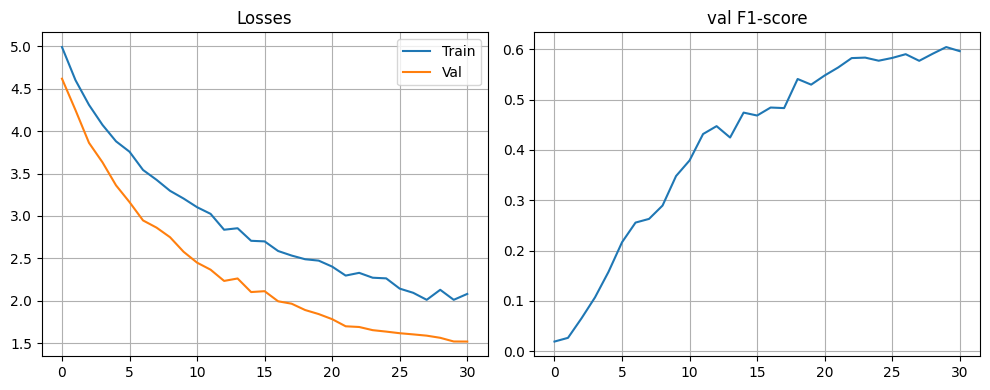

 16%|█▌        | 32/200 [01:13<06:27,  2.31s/it]

!!! NEW BEST MODEL !!!
Epoch 31: train_loss 2.0296041102244935, val_loss 1.5193308408443744, val_f1 0.6045561756956458


 16%|█▋        | 33/200 [01:15<06:22,  2.29s/it]

Epoch 32: train_loss 1.987082575929576, val_loss 1.587625604409438, val_f1 0.5898024845641447


 17%|█▋        | 34/200 [01:18<06:18,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 33: train_loss 1.900869895671976, val_loss 1.4610266777185292, val_f1 0.6192768818453891


 18%|█▊        | 35/200 [01:20<06:14,  2.27s/it]

Epoch 34: train_loss 1.9509859907216038, val_loss 1.5163055383242094, val_f1 0.6040612575584376


 18%|█▊        | 36/200 [01:22<06:12,  2.27s/it]

Epoch 35: train_loss 1.86279610929818, val_loss 1.4974921574959388, val_f1 0.6023743703501437


 18%|█▊        | 37/200 [01:24<06:09,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 36: train_loss 1.877830250509854, val_loss 1.4378319428517268, val_f1 0.6295394994808953


 19%|█▉        | 38/200 [01:27<06:07,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 37: train_loss 1.8594489179808518, val_loss 1.425825256567735, val_f1 0.6428496286382235


 20%|█▉        | 39/200 [01:29<06:04,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 38: train_loss 1.8183914710735452, val_loss 1.3807247968820424, val_f1 0.6456270910289


 20%|██        | 40/200 [01:31<06:03,  2.27s/it]

Epoch 39: train_loss 1.8196541440897975, val_loss 1.4648711131169245, val_f1 0.6085215343404612
Epoch 40: train_loss 1.844502695675554, val_loss 1.4478668708067675, val_f1 0.6217438866668719


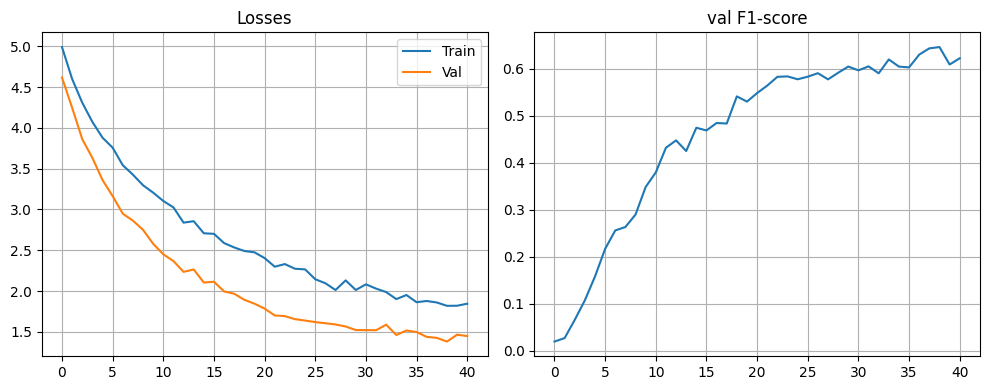

 21%|██        | 42/200 [01:36<06:02,  2.29s/it]

Epoch 41: train_loss 1.7906994901854416, val_loss 1.3712150775469267, val_f1 0.6289291788222886


 22%|██▏       | 43/200 [01:38<05:59,  2.29s/it]

Epoch 42: train_loss 1.7591609009380997, val_loss 1.3856168618569007, val_f1 0.6338342159317091


 22%|██▏       | 44/200 [01:40<05:55,  2.28s/it]

Epoch 43: train_loss 1.7733985555583034, val_loss 1.3726335213734553, val_f1 0.6244923232509795


 22%|██▎       | 45/200 [01:43<05:52,  2.27s/it]

Epoch 44: train_loss 1.7541021560800487, val_loss 1.3886799628917987, val_f1 0.6409539508687775


 23%|██▎       | 46/200 [01:45<05:49,  2.27s/it]

Epoch 45: train_loss 1.748742415987212, val_loss 1.4128974401033843, val_f1 0.6169371054068642


 24%|██▎       | 47/200 [01:47<05:47,  2.27s/it]

Epoch 46: train_loss 1.7333825949964852, val_loss 1.4135277913166926, val_f1 0.6279220185418888


 24%|██▍       | 48/200 [01:49<05:44,  2.27s/it]

Epoch 47: train_loss 1.7168750392979588, val_loss 1.3484932275918813, val_f1 0.6447838238659396


 24%|██▍       | 49/200 [01:52<05:42,  2.27s/it]

Epoch 48: train_loss 1.7842735011002113, val_loss 1.371232454593365, val_f1 0.6335165822945525


 25%|██▌       | 50/200 [01:54<05:39,  2.26s/it]

Epoch 49: train_loss 1.7505492794102635, val_loss 1.403183020078219, val_f1 0.6303249727915015
!!! NEW BEST MODEL !!!
Epoch 50: train_loss 1.7000844108647313, val_loss 1.3749922513961792, val_f1 0.6477089502308998


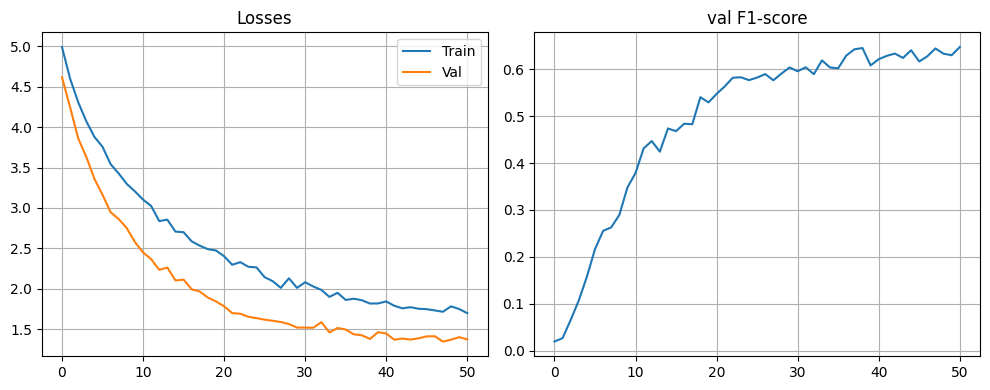

 26%|██▌       | 52/200 [01:59<05:38,  2.29s/it]

Epoch 51: train_loss 1.672902744391869, val_loss 1.37865477341872, val_f1 0.6331654385253183


 26%|██▋       | 53/200 [02:01<05:35,  2.28s/it]

Epoch 52: train_loss 1.6224585894880623, val_loss 1.4071862972699678, val_f1 0.6252975909540756


 27%|██▋       | 54/200 [02:03<05:32,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 53: train_loss 1.6972469913548436, val_loss 1.3745235204696655, val_f1 0.6491069206410965


 28%|██▊       | 55/200 [02:05<05:30,  2.28s/it]

Epoch 54: train_loss 1.6287483100233406, val_loss 1.3679911540104792, val_f1 0.6410528722136578


 28%|██▊       | 56/200 [02:08<05:27,  2.27s/it]

Epoch 55: train_loss 1.641012142444479, val_loss 1.3567482691544752, val_f1 0.6351019012097245


 28%|██▊       | 57/200 [02:10<05:25,  2.28s/it]

Epoch 56: train_loss 1.6523362727000797, val_loss 1.3986814480561476, val_f1 0.6392856994740012


 29%|██▉       | 58/200 [02:12<05:23,  2.28s/it]

Epoch 57: train_loss 1.6167004190642258, val_loss 1.3662088009027333, val_f1 0.6426364641284482


 30%|██▉       | 59/200 [02:14<05:20,  2.28s/it]

Epoch 58: train_loss 1.6614612299820473, val_loss 1.34431765629695, val_f1 0.6475577786602692


 30%|███       | 60/200 [02:17<05:19,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 59: train_loss 1.6599233356015435, val_loss 1.3383737619106586, val_f1 0.6551664115519537
Epoch 60: train_loss 1.6339703510547507, val_loss 1.3515064716339111, val_f1 0.640399229102386


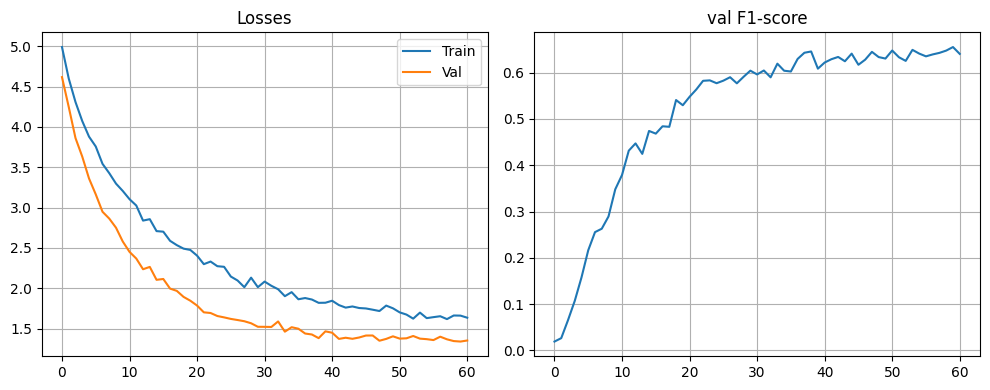

 31%|███       | 62/200 [02:21<05:17,  2.30s/it]

Epoch 61: train_loss 1.6017044947065155, val_loss 1.3258760067132802, val_f1 0.6499166782982021


 32%|███▏      | 63/200 [02:24<05:13,  2.29s/it]

Epoch 62: train_loss 1.6347750959725216, val_loss 1.3523584787662213, val_f1 0.6497816806499764


 32%|███▏      | 64/200 [02:26<05:10,  2.29s/it]

Epoch 63: train_loss 1.6954676776096738, val_loss 1.378678404367887, val_f1 0.6409820219206781


 32%|███▎      | 65/200 [02:28<05:07,  2.28s/it]

Epoch 64: train_loss 1.6357070002062568, val_loss 1.3519215400402362, val_f1 0.6478027220631001


 33%|███▎      | 66/200 [02:30<05:04,  2.27s/it]

Epoch 65: train_loss 1.6494415464072392, val_loss 1.4337129042698786, val_f1 0.6358886296559829


 34%|███▎      | 67/200 [02:33<05:03,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 66: train_loss 1.6231483755440548, val_loss 1.3488227037283091, val_f1 0.6552426939749999


 34%|███▍      | 68/200 [02:35<05:01,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 67: train_loss 1.6573812221658641, val_loss 1.335520597604605, val_f1 0.6573409024292102


 34%|███▍      | 69/200 [02:37<04:58,  2.28s/it]

Epoch 68: train_loss 1.6509010216285442, val_loss 1.398396061016963, val_f1 0.6415845198982286


 35%|███▌      | 70/200 [02:40<04:55,  2.28s/it]

Epoch 69: train_loss 1.6308278831942329, val_loss 1.3796016528056219, val_f1 0.6487938406983044
Epoch 70: train_loss 1.610475988223635, val_loss 1.3744126558303833, val_f1 0.6440225235903508


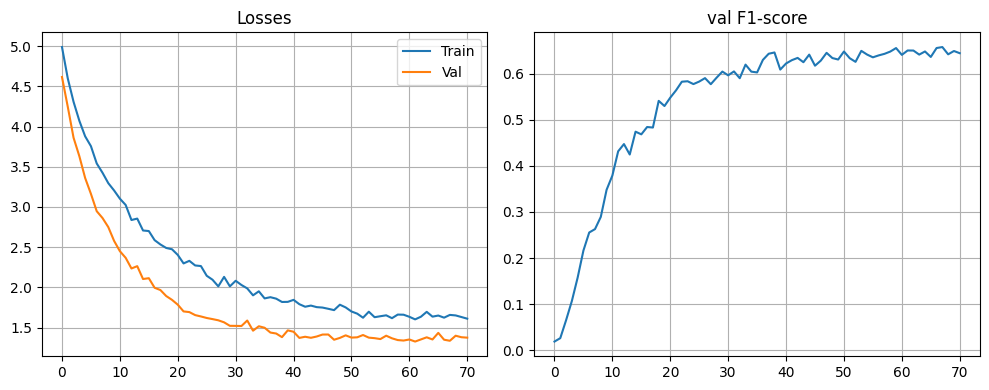

 36%|███▌      | 72/200 [02:44<04:53,  2.29s/it]

Epoch 71: train_loss 1.6674008903832271, val_loss 1.3800343733567457, val_f1 0.6415734895641121


 36%|███▋      | 73/200 [02:46<04:49,  2.28s/it]

Epoch 72: train_loss 1.596119971110903, val_loss 1.3634861157490656, val_f1 0.64163498678325


 37%|███▋      | 74/200 [02:49<04:46,  2.28s/it]

!!! NEW BEST MODEL !!!
Epoch 73: train_loss 1.5559363159640083, val_loss 1.3134011305295503, val_f1 0.6621379581130755


 38%|███▊      | 75/200 [02:51<04:44,  2.28s/it]

Epoch 74: train_loss 1.6691875252230415, val_loss 1.3764090171227088, val_f1 0.653013279722933


 38%|███▊      | 76/200 [02:53<04:41,  2.27s/it]

Epoch 75: train_loss 1.6121787367195919, val_loss 1.3558435348364024, val_f1 0.6533089592272592


 38%|███▊      | 77/200 [02:56<04:38,  2.27s/it]

Epoch 76: train_loss 1.6688021215899238, val_loss 1.347939133644104, val_f1 0.6619304344856655


 39%|███▉      | 78/200 [02:58<04:36,  2.27s/it]

Epoch 77: train_loss 1.7306038387890519, val_loss 1.3713382115730872, val_f1 0.6392796720443428


 40%|███▉      | 79/200 [03:00<04:33,  2.26s/it]

Epoch 78: train_loss 1.612769209105393, val_loss 1.3993370166191688, val_f1 0.6418743675741948


 40%|████      | 80/200 [03:02<04:31,  2.26s/it]

Epoch 79: train_loss 1.6085153283744023, val_loss 1.412376880645752, val_f1 0.6444024872102947
Epoch 80: train_loss 1.6237388027125392, val_loss 1.4204820853013258, val_f1 0.6479014554264925


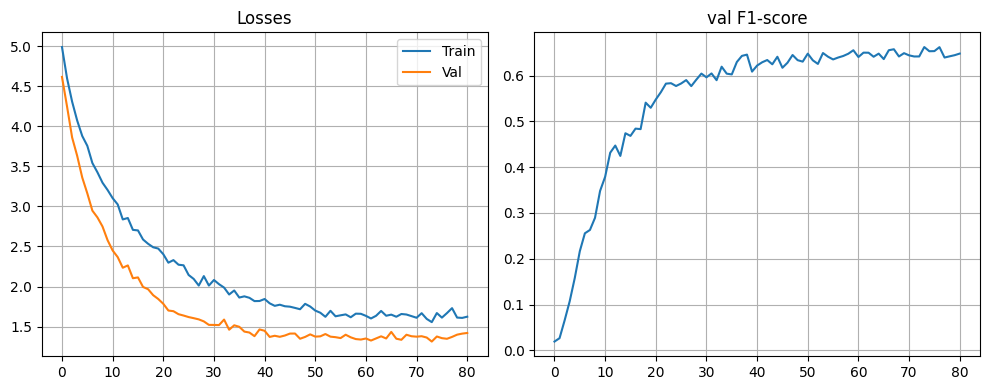

 41%|████      | 82/200 [03:07<04:29,  2.28s/it]

Epoch 81: train_loss 1.6140751304297611, val_loss 1.3691101532716017, val_f1 0.645435233323729


 42%|████▏     | 83/200 [03:09<04:25,  2.27s/it]

Epoch 82: train_loss 1.5582445531055844, val_loss 1.3631430589235747, val_f1 0.6480188765280691


 42%|████▏     | 84/200 [03:11<04:23,  2.27s/it]

Epoch 83: train_loss 1.5647101443389366, val_loss 1.3506323832731981, val_f1 0.6490918181667615


 42%|████▎     | 85/200 [03:14<04:20,  2.27s/it]

Epoch 84: train_loss 1.5638906421332524, val_loss 1.3437076990421002, val_f1 0.6487036280628776


 43%|████▎     | 86/200 [03:16<04:19,  2.28s/it]

Epoch 85: train_loss 1.6014480673033615, val_loss 1.3915921541360707, val_f1 0.6525338848265864


 44%|████▎     | 87/200 [03:18<04:17,  2.28s/it]

Epoch 86: train_loss 1.6134860268954574, val_loss 1.3691685474835908, val_f1 0.6544720350088623


 44%|████▍     | 88/200 [03:21<04:14,  2.27s/it]

Epoch 87: train_loss 1.6107974216855805, val_loss 1.3908449961588933, val_f1 0.6369415220066035


 44%|████▍     | 89/200 [03:23<04:11,  2.27s/it]

Epoch 88: train_loss 1.6367179854162808, val_loss 1.3733402398916392, val_f1 0.6499793014543782


 45%|████▌     | 90/200 [03:25<04:08,  2.26s/it]

Epoch 89: train_loss 1.557712587816962, val_loss 1.3818080333562999, val_f1 0.6519158504867885
Epoch 90: train_loss 1.6295083555681953, val_loss 1.3833736364658062, val_f1 0.6594309941748204


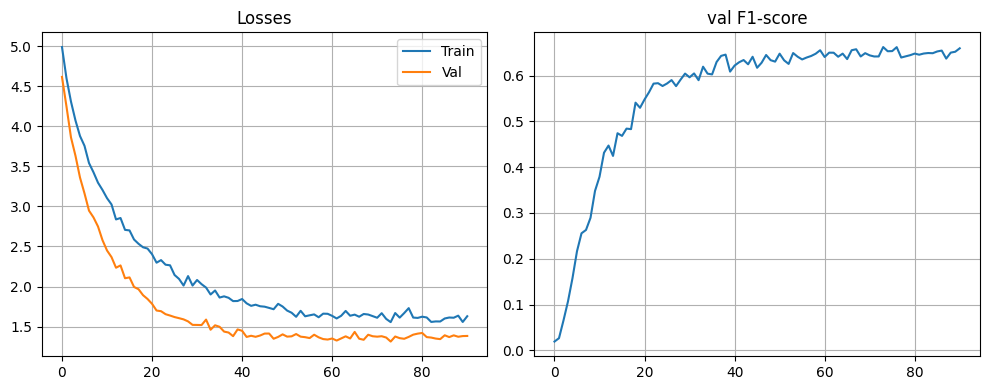

 46%|████▌     | 92/200 [03:30<04:06,  2.28s/it]

Epoch 91: train_loss 1.6214302490497459, val_loss 1.4257554457737849, val_f1 0.6494484983264515


 46%|████▋     | 93/200 [03:32<04:03,  2.28s/it]

Epoch 92: train_loss 1.6182251017669151, val_loss 1.3993516243421114, val_f1 0.6526364957328732


 47%|████▋     | 94/200 [03:34<04:00,  2.27s/it]

Epoch 93: train_loss 1.5913926239671379, val_loss 1.4593777564855723, val_f1 0.6439594451447401


 48%|████▊     | 95/200 [03:36<03:57,  2.26s/it]

Epoch 94: train_loss 1.5415571681384383, val_loss 1.4853209715623121, val_f1 0.6349007842418025


 48%|████▊     | 96/200 [03:39<03:55,  2.26s/it]

Epoch 95: train_loss 1.5510291559942837, val_loss 1.4372095328110914, val_f1 0.6444416133067051


 48%|████▊     | 97/200 [03:41<03:53,  2.26s/it]

Epoch 96: train_loss 1.6559655131964848, val_loss 1.402641800733713, val_f1 0.6564544123926401


 49%|████▉     | 98/200 [03:43<03:50,  2.26s/it]

Epoch 97: train_loss 1.603643117279842, val_loss 1.3801951866883497, val_f1 0.6551265448517183


 50%|████▉     | 99/200 [03:45<03:48,  2.26s/it]

Epoch 98: train_loss 1.586409803094535, val_loss 1.432629053409283, val_f1 0.6464673555203585


 50%|█████     | 100/200 [03:48<03:46,  2.26s/it]

Epoch 99: train_loss 1.5869981831517712, val_loss 1.4047053777254546, val_f1 0.6530679368857002
Epoch 100: train_loss 1.6152179117860466, val_loss 1.4258463749518762, val_f1 0.6548427762992793


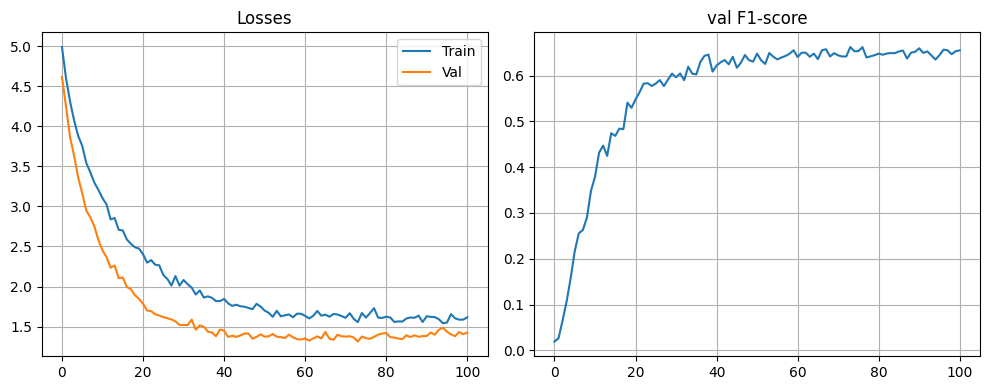

 51%|█████     | 102/200 [03:52<03:43,  2.28s/it]

Epoch 101: train_loss 1.6046072655710681, val_loss 1.4252133277746348, val_f1 0.650756531416942


 52%|█████▏    | 103/200 [03:55<03:40,  2.27s/it]

Epoch 102: train_loss 1.5548529419405708, val_loss 1.4411335174853985, val_f1 0.6476349929049982


 52%|█████▏    | 104/200 [03:57<03:37,  2.27s/it]

Epoch 103: train_loss 1.588828600686172, val_loss 1.3878574829835157, val_f1 0.6605621213224998


 52%|█████▎    | 105/200 [03:59<03:35,  2.26s/it]

Epoch 104: train_loss 1.5571503187048024, val_loss 1.4142904373315663, val_f1 0.6341202499691584


 53%|█████▎    | 106/200 [04:01<03:32,  2.26s/it]

Epoch 105: train_loss 1.5500793580351204, val_loss 1.4103076366277842, val_f1 0.65238446478238


 54%|█████▎    | 107/200 [04:04<03:29,  2.26s/it]

Epoch 106: train_loss 1.5572094095164333, val_loss 1.4254148098138661, val_f1 0.6543981242598755


 54%|█████▍    | 108/200 [04:06<03:27,  2.26s/it]

Epoch 107: train_loss 1.6242375949333454, val_loss 1.4025383912600005, val_f1 0.6575353807611021


 55%|█████▍    | 109/200 [04:08<03:25,  2.26s/it]

Epoch 108: train_loss 1.5745396655181358, val_loss 1.3874501540110662, val_f1 0.6556422293092472


 55%|█████▌    | 110/200 [04:10<03:23,  2.26s/it]

Epoch 109: train_loss 1.6490072176374238, val_loss 1.4078294772368212, val_f1 0.6566784004773615
Epoch 110: train_loss 1.579424081177547, val_loss 1.4187516157443707, val_f1 0.651476038903902


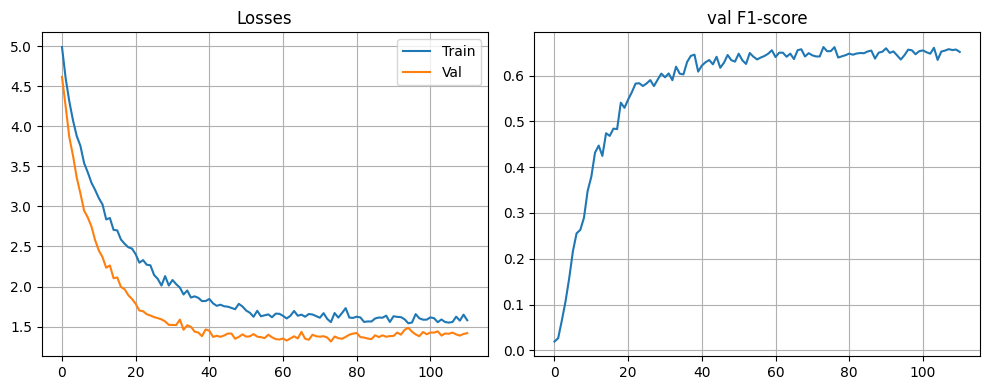

 56%|█████▌    | 112/200 [04:15<03:22,  2.30s/it]

Epoch 111: train_loss 1.5401961433476414, val_loss 1.4061432434962347, val_f1 0.6543128867976996


 56%|█████▋    | 113/200 [04:17<03:19,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 112: train_loss 1.5971544323296383, val_loss 1.429095405798692, val_f1 0.665172343061548


 57%|█████▋    | 114/200 [04:20<03:16,  2.29s/it]

Epoch 113: train_loss 1.6317312676331093, val_loss 1.4385519577906682, val_f1 0.6527068537869134


 57%|█████▊    | 115/200 [04:22<03:14,  2.28s/it]

Epoch 114: train_loss 1.5340676184358268, val_loss 1.4977633036099947, val_f1 0.6470241519599564


 58%|█████▊    | 116/200 [04:24<03:11,  2.28s/it]

Epoch 115: train_loss 1.6384996997899022, val_loss 1.418344681079571, val_f1 0.6605608194513066


 58%|█████▊    | 117/200 [04:27<03:08,  2.27s/it]

Epoch 116: train_loss 1.567665745472086, val_loss 1.4020978579154382, val_f1 0.6631157535262188


 59%|█████▉    | 118/200 [04:29<03:06,  2.27s/it]

Epoch 117: train_loss 1.6070356451231858, val_loss 1.3756582736968994, val_f1 0.6532564084865919


 60%|█████▉    | 119/200 [04:31<03:03,  2.27s/it]

Epoch 118: train_loss 1.6069807266366893, val_loss 1.4708201793523936, val_f1 0.6477979817777739


 60%|██████    | 120/200 [04:33<03:01,  2.27s/it]

Epoch 119: train_loss 1.5813328356578433, val_loss 1.399733387506925, val_f1 0.6530998499717576
Epoch 120: train_loss 1.6784855456187808, val_loss 1.4107558177067683, val_f1 0.6621106283314384


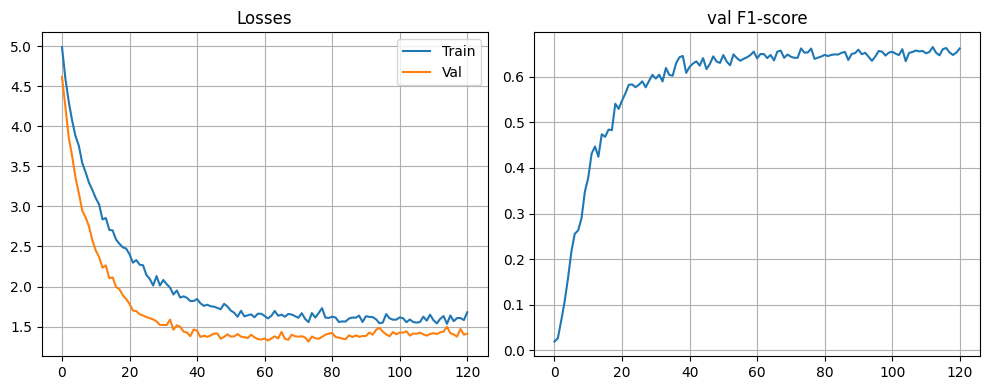

 61%|██████    | 122/200 [04:38<02:59,  2.30s/it]

Epoch 121: train_loss 1.5183472263401951, val_loss 1.435710650223952, val_f1 0.6548695940419388


 62%|██████▏   | 123/200 [04:40<02:56,  2.29s/it]

Epoch 122: train_loss 1.6701934872002437, val_loss 1.4768130504167998, val_f1 0.6471191281642732


 62%|██████▏   | 124/200 [04:43<02:53,  2.28s/it]

Epoch 123: train_loss 1.5488878735180558, val_loss 1.4228679950420673, val_f1 0.6460039318555579


 62%|██████▎   | 125/200 [04:45<02:50,  2.28s/it]

Epoch 124: train_loss 1.5427562861606992, val_loss 1.4755619580929096, val_f1 0.6483928118059381


 63%|██████▎   | 126/200 [04:47<02:48,  2.27s/it]

Epoch 125: train_loss 1.6256592273712158, val_loss 1.4467048645019531, val_f1 0.6510444108594855


 64%|██████▎   | 127/200 [04:49<02:45,  2.27s/it]

Epoch 126: train_loss 1.6547691287665531, val_loss 1.4644311391390288, val_f1 0.647540489555825


 64%|██████▍   | 128/200 [04:52<02:43,  2.27s/it]

Epoch 127: train_loss 1.5584580240578487, val_loss 1.5017376037744374, val_f1 0.6456383644724791


 64%|██████▍   | 129/200 [04:54<02:41,  2.28s/it]

Epoch 128: train_loss 1.516068516106441, val_loss 1.4669490502430842, val_f1 0.6520135441825642


 65%|██████▌   | 130/200 [04:56<02:38,  2.27s/it]

Epoch 129: train_loss 1.5933124977966835, val_loss 1.4505480894675622, val_f1 0.6586650179728248
Epoch 130: train_loss 1.5280192884905586, val_loss 1.4095233312019935, val_f1 0.6615604378515887


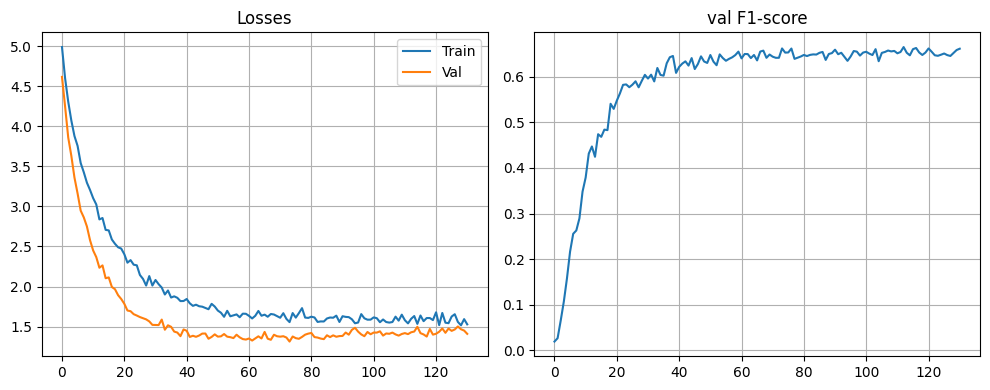

 66%|██████▌   | 132/200 [05:01<02:35,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 131: train_loss 1.5989570206609265, val_loss 1.4095893731484046, val_f1 0.6658484799002192


 66%|██████▋   | 133/200 [05:03<02:33,  2.29s/it]

Epoch 132: train_loss 1.536706015981477, val_loss 1.4419599037904005, val_f1 0.6533451684278226


 67%|██████▋   | 134/200 [05:05<02:30,  2.28s/it]

Epoch 133: train_loss 1.6155781170417522, val_loss 1.473427882561317, val_f1 0.6533723656788694


 68%|██████▊   | 135/200 [05:08<02:27,  2.27s/it]

Epoch 134: train_loss 1.5239109746341049, val_loss 1.498915277994596, val_f1 0.6541045268887447


 68%|██████▊   | 136/200 [05:10<02:25,  2.27s/it]

Epoch 135: train_loss 1.5460034608840942, val_loss 1.4163539042839637, val_f1 0.6594316059451468


 68%|██████▊   | 137/200 [05:12<02:22,  2.27s/it]

Epoch 136: train_loss 1.4584635249499618, val_loss 1.4530595816098726, val_f1 0.656229645857497


 69%|██████▉   | 138/200 [05:14<02:20,  2.27s/it]

Epoch 137: train_loss 1.5564813531678299, val_loss 1.4377448375408466, val_f1 0.6621190821627165


 70%|██████▉   | 139/200 [05:17<02:18,  2.27s/it]

Epoch 138: train_loss 1.556264359375526, val_loss 1.4578716113017156, val_f1 0.6564258837963137


 70%|███████   | 140/200 [05:19<02:15,  2.27s/it]

Epoch 139: train_loss 1.5718371292640423, val_loss 1.4544577598571777, val_f1 0.6621566939706315
Epoch 140: train_loss 1.5095665331544548, val_loss 1.464276359631465, val_f1 0.6596434199820028


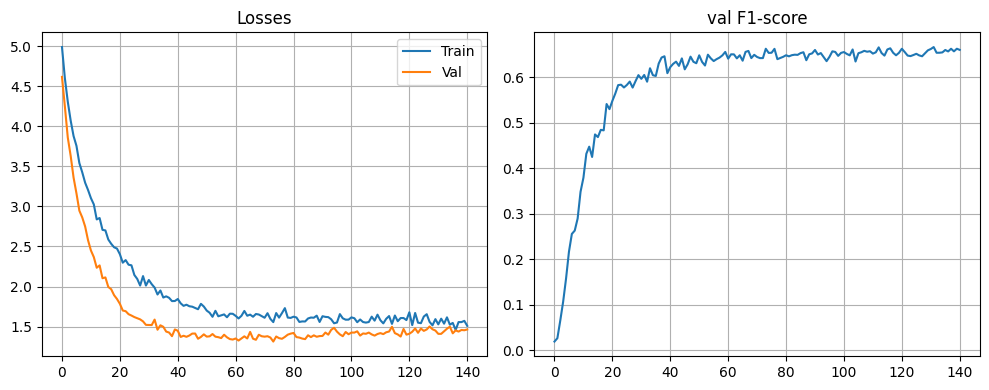

 71%|███████   | 142/200 [05:23<02:12,  2.29s/it]

!!! NEW BEST MODEL !!!
Epoch 141: train_loss 1.6216299780483903, val_loss 1.4805166537945087, val_f1 0.665959136260954


 72%|███████▏  | 143/200 [05:26<02:09,  2.28s/it]

Epoch 142: train_loss 1.67036785339487, val_loss 1.4948692963673518, val_f1 0.6522523479614946


 72%|███████▏  | 144/200 [05:28<02:07,  2.27s/it]

Epoch 143: train_loss 1.6197794552507072, val_loss 1.559110769858727, val_f1 0.6328167884366634


 72%|███████▎  | 145/200 [05:30<02:04,  2.27s/it]

Epoch 144: train_loss 1.6068923596678109, val_loss 1.5426655457570002, val_f1 0.6408976395332711


 73%|███████▎  | 146/200 [05:33<02:02,  2.27s/it]

Epoch 145: train_loss 1.5838716153440804, val_loss 1.5280795005651622, val_f1 0.6410299034785278


 74%|███████▎  | 147/200 [05:35<02:00,  2.27s/it]

Epoch 146: train_loss 1.6379635991721317, val_loss 1.4982014802786021, val_f1 0.6526538942036805


 74%|███████▍  | 148/200 [05:37<01:57,  2.27s/it]

Epoch 147: train_loss 1.5076293904205849, val_loss 1.454595685005188, val_f1 0.65875060201874


 74%|███████▍  | 149/200 [05:39<01:55,  2.27s/it]

!!! NEW BEST MODEL !!!
Epoch 148: train_loss 1.5974219050900689, val_loss 1.41966320001162, val_f1 0.6688018061770331


 75%|███████▌  | 150/200 [05:42<01:53,  2.27s/it]

Epoch 149: train_loss 1.5437012335349773, val_loss 1.503202612583454, val_f1 0.651299899916755
Epoch 150: train_loss 1.5334301899219382, val_loss 1.466921246968783, val_f1 0.659196437803056


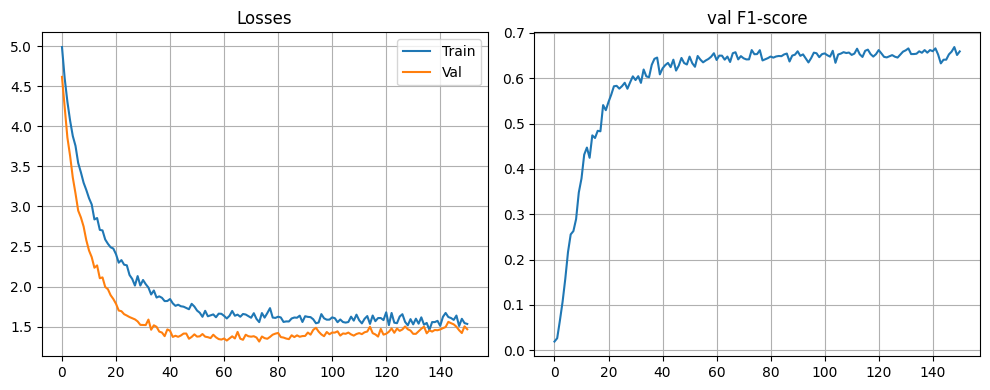

 76%|███████▌  | 152/200 [05:46<01:50,  2.29s/it]

Epoch 151: train_loss 1.5237071390809684, val_loss 1.4195457513515766, val_f1 0.6581306877094864


 76%|███████▋  | 153/200 [05:49<01:47,  2.28s/it]

Epoch 152: train_loss 1.5283841799045432, val_loss 1.4678301077622633, val_f1 0.6560144979462045


 77%|███████▋  | 154/200 [05:51<01:44,  2.28s/it]

Epoch 153: train_loss 1.642092778764922, val_loss 1.4365745599453266, val_f1 0.6637088435049167


 78%|███████▊  | 155/200 [05:53<01:42,  2.28s/it]

Epoch 154: train_loss 1.6150853305027402, val_loss 1.460195312133202, val_f1 0.6651454345462408


 78%|███████▊  | 156/200 [05:55<01:39,  2.27s/it]

Epoch 155: train_loss 1.4879377422661617, val_loss 1.4288183725797212, val_f1 0.6645355788484676


 78%|███████▊  | 157/200 [05:58<01:37,  2.26s/it]

Epoch 156: train_loss 1.488887803307895, val_loss 1.4371665165974543, val_f1 0.6611160196402214


 79%|███████▉  | 158/200 [06:00<01:35,  2.27s/it]

Epoch 157: train_loss 1.5351867716887901, val_loss 1.520151294194735, val_f1 0.6568217635463212


 80%|███████▉  | 159/200 [06:02<01:32,  2.27s/it]

Epoch 158: train_loss 1.566784932695586, val_loss 1.5008035623110259, val_f1 0.6512630822433152


 80%|████████  | 160/200 [06:04<01:30,  2.27s/it]

Epoch 159: train_loss 1.5616303230154103, val_loss 1.4729918424899762, val_f1 0.6599816617822672
Epoch 160: train_loss 1.591594650827605, val_loss 1.50717294216156, val_f1 0.6485439100398601


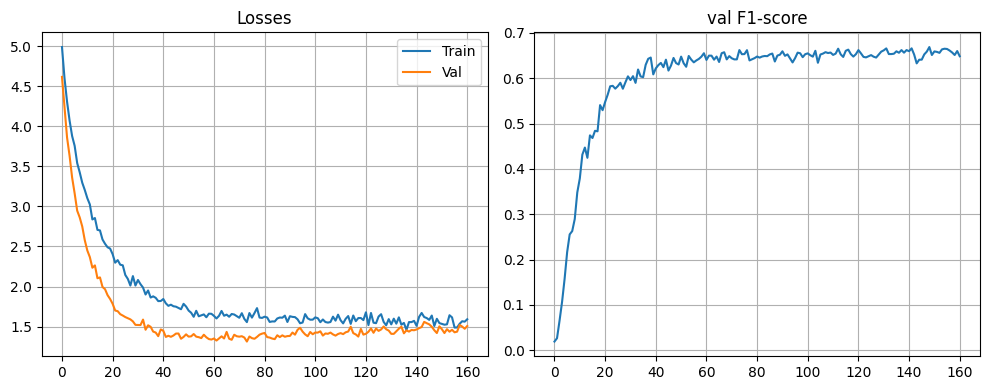

 81%|████████  | 162/200 [06:09<01:26,  2.28s/it]

Epoch 161: train_loss 1.55030069268983, val_loss 1.5405774666712835, val_f1 0.6316241367257658


 82%|████████▏ | 163/200 [06:11<01:24,  2.28s/it]

Epoch 162: train_loss 1.5924330497610157, val_loss 1.558367344049307, val_f1 0.649279391477452


 82%|████████▏ | 164/200 [06:14<01:21,  2.28s/it]

Epoch 163: train_loss 1.6291038044567765, val_loss 1.516918915968675, val_f1 0.6564274500465486


 82%|████████▎ | 165/200 [06:16<01:19,  2.27s/it]

Epoch 164: train_loss 1.4550358098128746, val_loss 1.5115530765973604, val_f1 0.6444188049166389


 83%|████████▎ | 166/200 [06:18<01:17,  2.27s/it]

Epoch 165: train_loss 1.607537532674855, val_loss 1.562453875174889, val_f1 0.6458475521882209


 84%|████████▎ | 167/200 [06:20<01:14,  2.27s/it]

Epoch 166: train_loss 1.5497173399760806, val_loss 1.5784080487031202, val_f1 0.6436771774237271


 84%|████████▍ | 168/200 [06:23<01:12,  2.27s/it]

Epoch 167: train_loss 1.544435871058497, val_loss 1.4491869394595807, val_f1 0.6617384301868005


 84%|████████▍ | 169/200 [06:25<01:10,  2.27s/it]

Epoch 168: train_loss 1.5379513789867532, val_loss 1.5291118438427265, val_f1 0.6487421287413337


 85%|████████▌ | 170/200 [06:27<01:07,  2.27s/it]

Epoch 169: train_loss 1.5613352142531296, val_loss 1.519851253582881, val_f1 0.6490285700491404
!!! NEW BEST MODEL !!!
Epoch 170: train_loss 1.5576168915321087, val_loss 1.4865097724474394, val_f1 0.6709988399226948


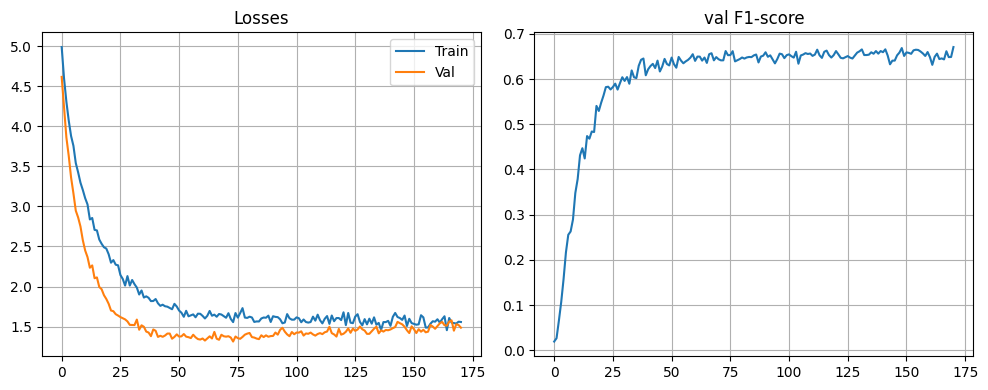

 86%|████████▌ | 172/200 [06:32<01:04,  2.29s/it]

Epoch 171: train_loss 1.5571438690711712, val_loss 1.461727105654203, val_f1 0.6584917125718402


 86%|████████▋ | 173/200 [06:34<01:01,  2.29s/it]

Epoch 172: train_loss 1.5788789453177616, val_loss 1.4931555161109338, val_f1 0.6562095935021798


 87%|████████▋ | 174/200 [06:36<00:59,  2.30s/it]

Epoch 173: train_loss 1.5500559477970517, val_loss 1.4647391117536104, val_f1 0.6595371221580543


 88%|████████▊ | 175/200 [06:39<00:57,  2.29s/it]

Epoch 174: train_loss 1.5354572781201066, val_loss 1.4623929170461802, val_f1 0.6644260959145477


 88%|████████▊ | 176/200 [06:41<00:54,  2.28s/it]

Epoch 175: train_loss 1.4970053434371948, val_loss 1.450315420444195, val_f1 0.665718081412707


 88%|████████▊ | 177/200 [06:43<00:52,  2.27s/it]

Epoch 176: train_loss 1.5903575379272987, val_loss 1.4910078140405507, val_f1 0.649766439258373


 89%|████████▉ | 178/200 [06:45<00:49,  2.27s/it]

Epoch 177: train_loss 1.5257932276561343, val_loss 1.529741122172429, val_f1 0.65565464849589


 90%|████████▉ | 179/200 [06:48<00:47,  2.27s/it]

Epoch 178: train_loss 1.5973140247936906, val_loss 1.5820307364830604, val_f1 0.6489766604588668


 90%|█████████ | 180/200 [06:50<00:45,  2.26s/it]

Epoch 179: train_loss 1.5150285342644, val_loss 1.469432152234591, val_f1 0.6667392573503452
Epoch 180: train_loss 1.4886739418424408, val_loss 1.4596316539324248, val_f1 0.6602605309052159


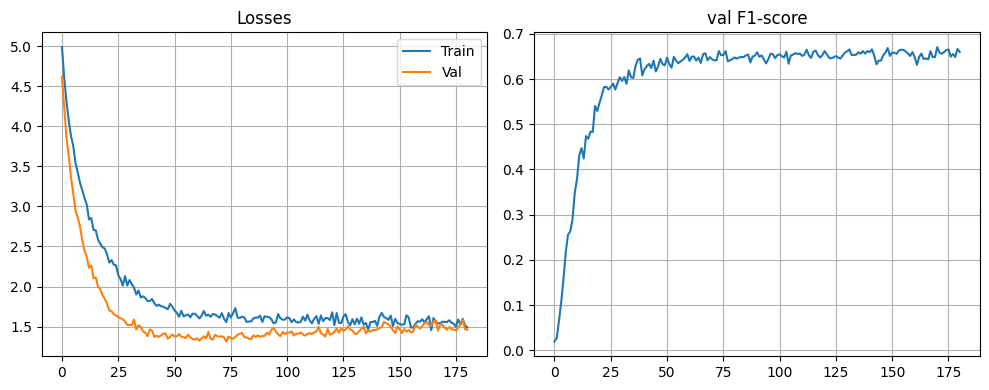

 91%|█████████ | 182/200 [06:55<00:41,  2.29s/it]

Epoch 181: train_loss 1.5346603352448036, val_loss 1.4290423393249512, val_f1 0.6590820120313033


 92%|█████████▏| 183/200 [06:57<00:38,  2.29s/it]

Epoch 182: train_loss 1.5298449006573906, val_loss 1.479755429121164, val_f1 0.657263618071038


 92%|█████████▏| 184/200 [06:59<00:36,  2.28s/it]

Epoch 183: train_loss 1.570563789071708, val_loss 1.4517042545171885, val_f1 0.666956357988803


 92%|█████████▎| 185/200 [07:01<00:34,  2.27s/it]

Epoch 184: train_loss 1.5515156573262707, val_loss 1.4959963193306556, val_f1 0.6468790991866374


 93%|█████████▎| 186/200 [07:04<00:31,  2.27s/it]

Epoch 185: train_loss 1.5086649574082474, val_loss 1.458550554055434, val_f1 0.661552442176324


 94%|█████████▎| 187/200 [07:06<00:29,  2.28s/it]

Epoch 186: train_loss 1.564774542019285, val_loss 1.5296018307025616, val_f1 0.6522498146334686


 94%|█████████▍| 188/200 [07:08<00:27,  2.28s/it]

Epoch 187: train_loss 1.5614378000127858, val_loss 1.4671414723763099, val_f1 0.6624045637251563


 94%|█████████▍| 189/200 [07:10<00:24,  2.27s/it]

Epoch 188: train_loss 1.5290889041177158, val_loss 1.4961493932283843, val_f1 0.6595011673038317


 95%|█████████▌| 190/200 [07:13<00:22,  2.28s/it]

Epoch 189: train_loss 1.4782203559217781, val_loss 1.5363260415884166, val_f1 0.6692393353316293
Epoch 190: train_loss 1.5095859848219773, val_loss 1.5320129211132343, val_f1 0.661465728191813


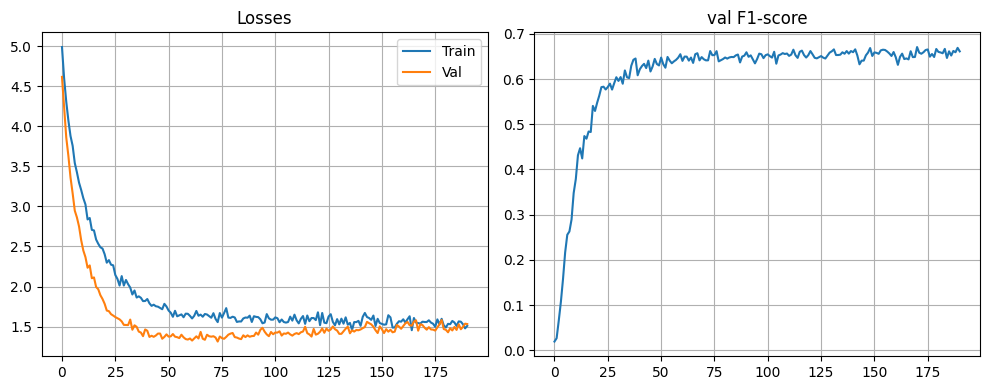

 96%|█████████▌| 192/200 [07:17<00:18,  2.30s/it]

Epoch 191: train_loss 1.539812836153754, val_loss 1.5063514342674842, val_f1 0.6576318873617054


 96%|█████████▋| 193/200 [07:20<00:16,  2.29s/it]

Epoch 192: train_loss 1.5894234344877045, val_loss 1.478890712444599, val_f1 0.6609962278036075


 97%|█████████▋| 194/200 [07:22<00:13,  2.27s/it]

Epoch 193: train_loss 1.4969162447699185, val_loss 1.4860842319635243, val_f1 0.6685300335192405


 98%|█████████▊| 195/200 [07:24<00:11,  2.27s/it]

Epoch 194: train_loss 1.5184094823639969, val_loss 1.4685325897656953, val_f1 0.6636409996268006


 98%|█████████▊| 196/200 [07:26<00:09,  2.27s/it]

Epoch 195: train_loss 1.5698964266941464, val_loss 1.5086614718803992, val_f1 0.6589337021937556


 98%|█████████▊| 197/200 [07:29<00:06,  2.27s/it]

Epoch 196: train_loss 1.566386576356559, val_loss 1.5445995055712187, val_f1 0.6514595600785699


 99%|█████████▉| 198/200 [07:31<00:04,  2.27s/it]

Epoch 197: train_loss 1.5586014451651737, val_loss 1.506564470437857, val_f1 0.6554978836047675


100%|█████████▉| 199/200 [07:33<00:02,  2.26s/it]

Epoch 198: train_loss 1.5309402284951046, val_loss 1.5204105010399451, val_f1 0.6496433758050502
Epoch 199: train_loss 1.538188835670208, val_loss 1.48482163135822, val_f1 0.6693450216203222


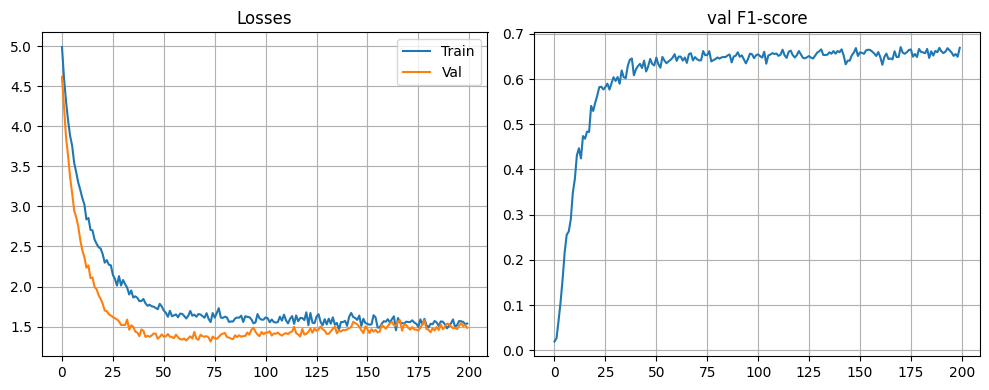

100%|██████████| 200/200 [07:36<00:00,  2.28s/it]

Best score: 0.6709988399226948


PockemonModel(
  (conv_net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool2d(kernel

In [22]:
model = ic(PockemonModel(
    img_shape=IN_SHAPE,
    in_ch=3,
    hidden_ch=[32, 64, 128, 256],
    hidden_fc=[256],
    out_dim=150,
    conv_dropout=0.1
))

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

train_loop(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    optimizer=optimizer,
    criterion=criterion,
    model_name="best_model_003.pth",
    num_epoches=200
)


ic| PockemonModel(
        img_shape=(224, 224),
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256, 128],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()


!!! NEW BEST MODEL !!!
Epoch 0: train_loss 3.9703298848250816, val_loss 3.1315746307373047, val_f1 0.3504772799196992


  2%|▏         | 2/100 [00:19<16:16,  9.96s/it]

!!! NEW BEST MODEL !!!
Epoch 1: train_loss 3.9341724987687736, val_loss 3.0097398391136756, val_f1 0.3831130633180072


  3%|▎         | 3/100 [00:29<15:38,  9.67s/it]

Epoch 2: train_loss 3.924712896347046, val_loss 3.066094306799082, val_f1 0.3580032045518803


  4%|▍         | 4/100 [00:38<15:14,  9.52s/it]

Epoch 3: train_loss 3.9668272774795006, val_loss 3.0006670401646542, val_f1 0.37364762612654884


  5%|▌         | 5/100 [00:47<14:59,  9.47s/it]

Epoch 4: train_loss 3.8746195743823875, val_loss 3.0285169161283054, val_f1 0.37225012208706465


  6%|▌         | 6/100 [00:57<14:46,  9.43s/it]

Epoch 5: train_loss 3.916839887355936, val_loss 3.0028064984541674, val_f1 0.3631083440277502


  7%|▋         | 7/100 [01:06<14:33,  9.39s/it]

Epoch 6: train_loss 3.8958958592908135, val_loss 3.0148312678703895, val_f1 0.3663578249706772


  8%|▊         | 8/100 [01:15<14:21,  9.37s/it]

Epoch 7: train_loss 3.921483138511921, val_loss 2.9944451588850756, val_f1 0.36820065153850834


  9%|▉         | 9/100 [01:25<14:10,  9.35s/it]

Epoch 8: train_loss 3.9223394558347504, val_loss 2.9648285462306094, val_f1 0.3504887354501682


 10%|█         | 10/100 [01:35<14:13,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 9: train_loss 3.9082297621102167, val_loss 2.9689036332643948, val_f1 0.38697377500298635
Epoch 10: train_loss 3.9259756844619225, val_loss 2.9530458450317383, val_f1 0.3868727349270073


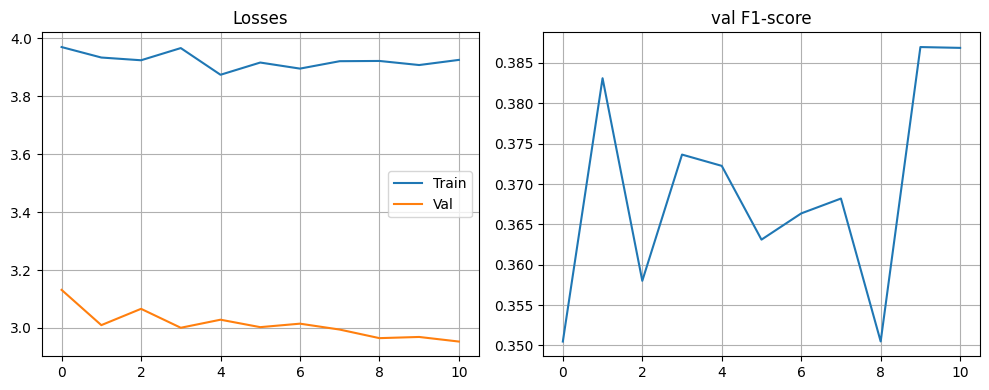

 12%|█▏        | 12/100 [01:53<13:49,  9.43s/it]

Epoch 11: train_loss 3.838655874646943, val_loss 2.9849249766423154, val_f1 0.37768001606985774


 13%|█▎        | 13/100 [02:03<13:50,  9.54s/it]

!!! NEW BEST MODEL !!!
Epoch 12: train_loss 3.9453544452272613, val_loss 2.9200599927168627, val_f1 0.3933657589330676


 14%|█▍        | 14/100 [02:13<13:47,  9.62s/it]

!!! NEW BEST MODEL !!!
Epoch 13: train_loss 3.813959236802726, val_loss 2.9282954105964074, val_f1 0.40035187178648457


 15%|█▌        | 15/100 [02:22<13:29,  9.53s/it]

Epoch 14: train_loss 3.83369491018098, val_loss 2.9597336879143348, val_f1 0.39134671651356256


 16%|█▌        | 16/100 [02:32<13:27,  9.61s/it]

!!! NEW BEST MODEL !!!
Epoch 15: train_loss 3.843402418596991, val_loss 2.94523470218365, val_f1 0.4015154434745304


 17%|█▋        | 17/100 [02:41<13:10,  9.52s/it]

Epoch 16: train_loss 3.900128487882943, val_loss 2.9590570009671726, val_f1 0.36972944444975614


 18%|█▊        | 18/100 [02:51<12:55,  9.46s/it]

Epoch 17: train_loss 3.8477171700576256, val_loss 2.9398118349222035, val_f1 0.3870504839532828


 19%|█▉        | 19/100 [03:00<12:42,  9.41s/it]

Epoch 18: train_loss 3.8690975945571373, val_loss 2.9168533912071815, val_f1 0.3903157857378934


 20%|██        | 20/100 [03:10<12:41,  9.52s/it]

!!! NEW BEST MODEL !!!
Epoch 19: train_loss 3.838724498091073, val_loss 2.9202960454500637, val_f1 0.40182082082395526
Epoch 20: train_loss 3.794866241257766, val_loss 3.013143099271334, val_f1 0.36287393529250894


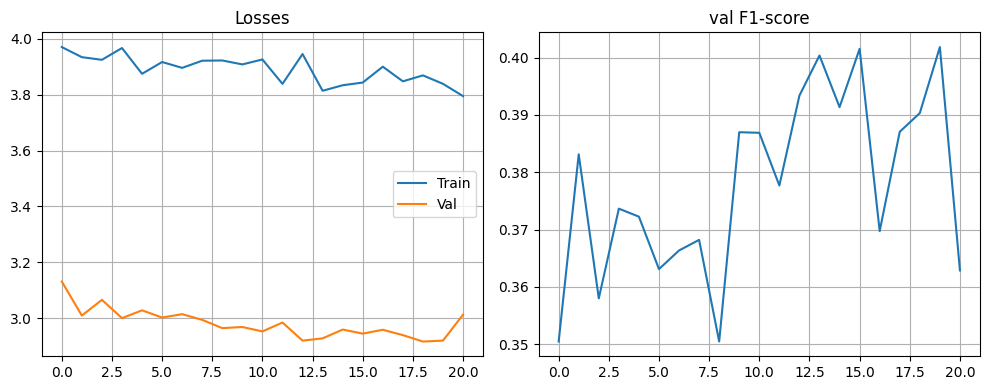

 22%|██▏       | 22/100 [03:29<12:16,  9.44s/it]

Epoch 21: train_loss 3.8683951969804435, val_loss 2.898098743878878, val_f1 0.39937882241455963


 23%|██▎       | 23/100 [03:38<12:14,  9.54s/it]

!!! NEW BEST MODEL !!!
Epoch 22: train_loss 3.7648590515399802, val_loss 2.884911977327787, val_f1 0.4157447339919882


 24%|██▍       | 24/100 [03:48<12:00,  9.47s/it]

Epoch 23: train_loss 3.748108074582856, val_loss 2.9477069561298075, val_f1 0.3713028262404695


 25%|██▌       | 25/100 [03:57<11:46,  9.42s/it]

Epoch 24: train_loss 3.803044919309945, val_loss 2.91093582373399, val_f1 0.4013347160773572


 26%|██▌       | 26/100 [04:06<11:34,  9.39s/it]

Epoch 25: train_loss 3.8418277460953285, val_loss 2.862787760221041, val_f1 0.38815002543982413


 27%|██▋       | 27/100 [04:16<11:24,  9.38s/it]

Epoch 26: train_loss 3.8340658319407495, val_loss 2.8733730499561014, val_f1 0.3935482441304898


 28%|██▊       | 28/100 [04:25<11:13,  9.36s/it]

Epoch 27: train_loss 3.778356437025399, val_loss 2.8976568625523496, val_f1 0.3971210432520535


 29%|██▉       | 29/100 [04:34<11:03,  9.34s/it]

Epoch 28: train_loss 3.8072146793891646, val_loss 2.897382534467257, val_f1 0.3965102360376325


 30%|███       | 30/100 [04:43<10:53,  9.33s/it]

Epoch 29: train_loss 3.8222778254541856, val_loss 2.8878842133742113, val_f1 0.4035944355487509
Epoch 30: train_loss 3.8108884301678887, val_loss 2.8812610736260047, val_f1 0.39066678192167276


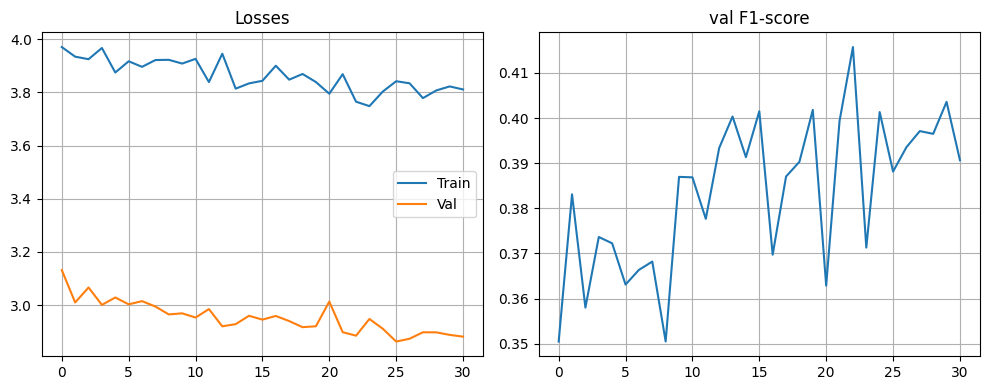

 32%|███▏      | 32/100 [05:02<10:35,  9.35s/it]

Epoch 31: train_loss 3.79164692451214, val_loss 2.8661193480858436, val_f1 0.4022562061925258


 33%|███▎      | 33/100 [05:12<10:25,  9.34s/it]

Epoch 32: train_loss 3.7680840492248535, val_loss 2.8016022168673, val_f1 0.4143750330595266


 34%|███▍      | 34/100 [05:21<10:25,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 33: train_loss 3.783039290329506, val_loss 2.787371378678542, val_f1 0.41720168492481374


 35%|███▌      | 35/100 [05:31<10:12,  9.43s/it]

Epoch 34: train_loss 3.7671981926622062, val_loss 2.848487909023578, val_f1 0.41076675991173534


 36%|███▌      | 36/100 [05:40<10:01,  9.40s/it]

Epoch 35: train_loss 3.713793524380388, val_loss 2.804488072028527, val_f1 0.41270850968263173


 37%|███▋      | 37/100 [05:49<09:51,  9.38s/it]

Epoch 36: train_loss 3.7185198027512123, val_loss 2.8630385949061465, val_f1 0.3907681380756577


 38%|███▊      | 38/100 [05:59<09:40,  9.36s/it]

Epoch 37: train_loss 3.727400886601415, val_loss 2.801033588556143, val_f1 0.41012965697660814


 39%|███▉      | 39/100 [06:08<09:30,  9.36s/it]

Epoch 38: train_loss 3.7657434364845015, val_loss 2.8104305817530704, val_f1 0.40820253389400446


 40%|████      | 40/100 [06:17<09:20,  9.35s/it]

Epoch 39: train_loss 3.7455404955765297, val_loss 2.8070600766402025, val_f1 0.40351376292666846
Epoch 40: train_loss 3.7784387818698226, val_loss 2.7668928916637716, val_f1 0.41194424391351686


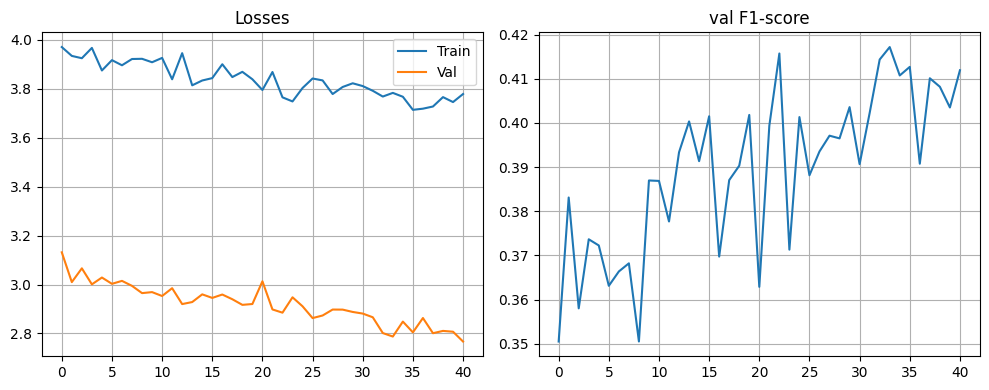

 42%|████▏     | 42/100 [06:36<09:03,  9.36s/it]

Epoch 41: train_loss 3.763290923217247, val_loss 2.776689786177415, val_f1 0.39751923556934327


 43%|████▎     | 43/100 [06:45<08:53,  9.35s/it]

Epoch 42: train_loss 3.737655623205777, val_loss 2.8416007298689623, val_f1 0.39266887278558793


 44%|████▍     | 44/100 [06:55<08:43,  9.34s/it]

Epoch 43: train_loss 3.6927325561128814, val_loss 2.7861216251666727, val_f1 0.39684130132737977


 45%|████▌     | 45/100 [07:04<08:33,  9.33s/it]

Epoch 44: train_loss 3.681169559215677, val_loss 2.824477800956139, val_f1 0.4059416439168717


 46%|████▌     | 46/100 [07:13<08:23,  9.33s/it]

Epoch 45: train_loss 3.7553520449276627, val_loss 2.798996851994441, val_f1 0.3886352207044718


 47%|████▋     | 47/100 [07:23<08:14,  9.32s/it]

Epoch 46: train_loss 3.645393124942122, val_loss 2.8205836369441104, val_f1 0.40751512636594794


 48%|████▊     | 48/100 [07:32<08:12,  9.46s/it]

!!! NEW BEST MODEL !!!
Epoch 47: train_loss 3.7342982374388596, val_loss 2.750761087124164, val_f1 0.4213817409652221


 49%|████▉     | 49/100 [07:42<08:00,  9.42s/it]

Epoch 48: train_loss 3.710453074553917, val_loss 2.7718250934894266, val_f1 0.4066103946359482


 50%|█████     | 50/100 [07:51<07:49,  9.39s/it]

Epoch 49: train_loss 3.721901589426501, val_loss 2.754722466835609, val_f1 0.4143374691985288
!!! NEW BEST MODEL !!!
Epoch 50: train_loss 3.7806997052554427, val_loss 2.7788795141073375, val_f1 0.4303476559356656


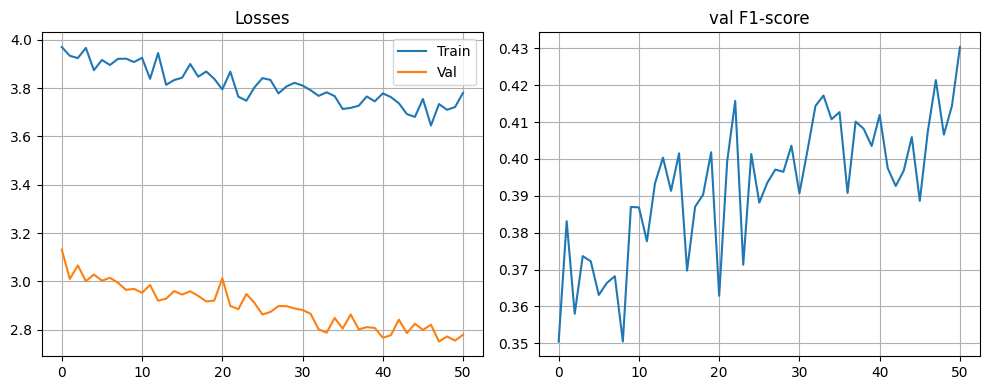

 52%|█████▏    | 52/100 [08:10<07:34,  9.46s/it]

Epoch 51: train_loss 3.765047369332149, val_loss 2.677871300623967, val_f1 0.43031826641288345


 53%|█████▎    | 53/100 [08:20<07:22,  9.40s/it]

Epoch 52: train_loss 3.723807195137287, val_loss 2.7751844112689676, val_f1 0.4083220050111763


 54%|█████▍    | 54/100 [08:29<07:11,  9.39s/it]

Epoch 53: train_loss 3.638182853830272, val_loss 2.7875608114095836, val_f1 0.4302032878786332


 55%|█████▌    | 55/100 [08:38<07:01,  9.37s/it]

Epoch 54: train_loss 3.676317576704354, val_loss 2.7913368298457217, val_f1 0.41561656285640597


 56%|█████▌    | 56/100 [08:48<06:51,  9.35s/it]

Epoch 55: train_loss 3.677205126861046, val_loss 2.730420479407677, val_f1 0.412453477969684


 57%|█████▋    | 57/100 [08:57<06:41,  9.35s/it]

Epoch 56: train_loss 3.702420029146918, val_loss 2.7304500066317043, val_f1 0.42030639256524205


 58%|█████▊    | 58/100 [09:06<06:32,  9.34s/it]

Epoch 57: train_loss 3.642029112782972, val_loss 2.7182775827554555, val_f1 0.40452878361250394


 59%|█████▉    | 59/100 [09:16<06:28,  9.48s/it]

!!! NEW BEST MODEL !!!
Epoch 58: train_loss 3.687546869804119, val_loss 2.7360790142646203, val_f1 0.4362708486571271


 60%|██████    | 60/100 [09:25<06:17,  9.43s/it]

Epoch 59: train_loss 3.6960177750423036, val_loss 2.736134639153114, val_f1 0.4238285726386037
Epoch 60: train_loss 3.7076488198905158, val_loss 2.721717045857356, val_f1 0.41368691171633076


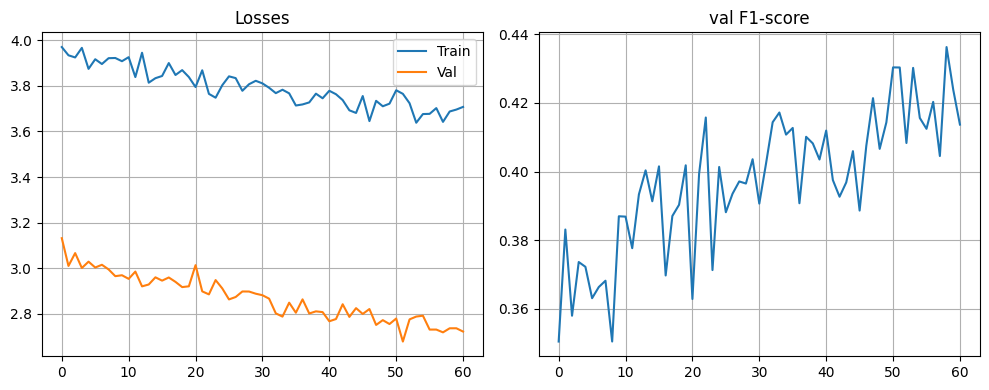

 62%|██████▏   | 62/100 [09:44<05:57,  9.39s/it]

Epoch 61: train_loss 3.683055335077746, val_loss 2.699922745044415, val_f1 0.4320084533795807


 63%|██████▎   | 63/100 [09:53<05:46,  9.37s/it]

Epoch 62: train_loss 3.6766197845853608, val_loss 2.7557628521552453, val_f1 0.4139100710523018


 64%|██████▍   | 64/100 [10:03<05:36,  9.35s/it]

Epoch 63: train_loss 3.635288189197409, val_loss 2.713045597076416, val_f1 0.4151350349238899


 65%|██████▌   | 65/100 [10:12<05:26,  9.34s/it]

Epoch 64: train_loss 3.7012441076081375, val_loss 2.7158826864682712, val_f1 0.4081050241170393


 66%|██████▌   | 66/100 [10:21<05:17,  9.33s/it]

Epoch 65: train_loss 3.6285109273318588, val_loss 2.6906898205096903, val_f1 0.43285174084155953


 67%|██████▋   | 67/100 [10:31<05:07,  9.33s/it]

Epoch 66: train_loss 3.619809052039837, val_loss 2.7300470425532413, val_f1 0.41526931086798374


 68%|██████▊   | 68/100 [10:40<04:58,  9.32s/it]

Epoch 67: train_loss 3.654015467084687, val_loss 2.769727578529945, val_f1 0.39789570888321674


 69%|██████▉   | 69/100 [10:49<04:48,  9.32s/it]

Epoch 68: train_loss 3.6519190031906654, val_loss 2.7315876483917236, val_f1 0.4245815506357066


 70%|███████   | 70/100 [10:59<04:39,  9.32s/it]

Epoch 69: train_loss 3.7116643806983687, val_loss 2.6759610909682054, val_f1 0.40609165872141406
Epoch 70: train_loss 3.648653145494132, val_loss 2.678977214373075, val_f1 0.408182917003499


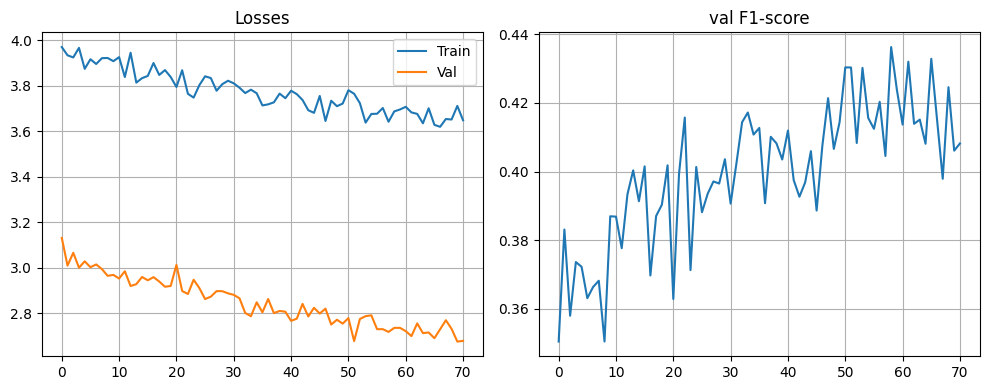

 72%|███████▏  | 72/100 [11:17<04:21,  9.35s/it]

Epoch 71: train_loss 3.6247376655710153, val_loss 2.704408884048462, val_f1 0.4214552768159845


 73%|███████▎  | 73/100 [11:27<04:12,  9.34s/it]

Epoch 72: train_loss 3.6767069964573302, val_loss 2.7177026455218973, val_f1 0.4154686644400323


 74%|███████▍  | 74/100 [11:36<04:02,  9.33s/it]

Epoch 73: train_loss 3.647036807290439, val_loss 2.674061206670908, val_f1 0.4213813914866728


 75%|███████▌  | 75/100 [11:45<03:53,  9.32s/it]

Epoch 74: train_loss 3.6125850759703537, val_loss 2.6959009170532227, val_f1 0.4204064214252444


 76%|███████▌  | 76/100 [11:55<03:43,  9.32s/it]

Epoch 75: train_loss 3.644300543028733, val_loss 2.6824481120476356, val_f1 0.41417344997064465


 77%|███████▋  | 77/100 [12:04<03:34,  9.32s/it]

Epoch 76: train_loss 3.6549618573024354, val_loss 2.684794077506432, val_f1 0.41198536512330347


 78%|███████▊  | 78/100 [12:13<03:24,  9.31s/it]

Epoch 77: train_loss 3.6266782201569656, val_loss 2.6727682993962216, val_f1 0.41088632533256125


 79%|███████▉  | 79/100 [12:22<03:15,  9.31s/it]

Epoch 78: train_loss 3.606120997461779, val_loss 2.742709233210637, val_f1 0.4213267763310791


 80%|████████  | 80/100 [12:32<03:06,  9.31s/it]

Epoch 79: train_loss 3.6085707154767266, val_loss 2.6615106692680945, val_f1 0.41121461041177826
Epoch 80: train_loss 3.6058670159043937, val_loss 2.694896019422091, val_f1 0.4182426079833107


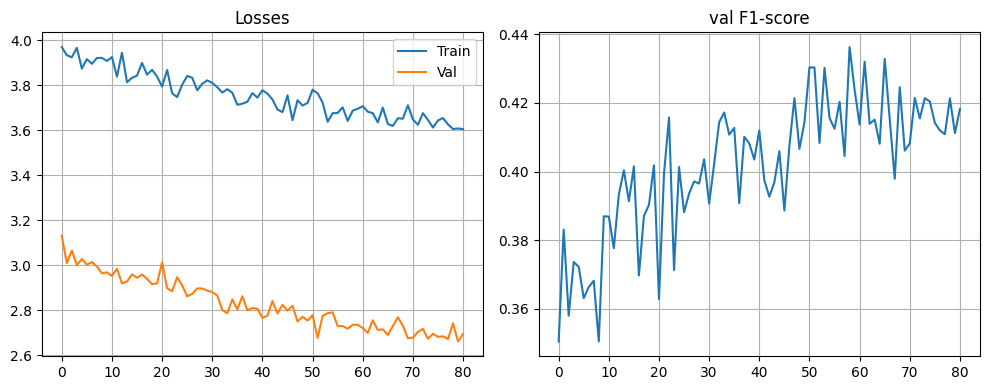

 82%|████████▏ | 82/100 [12:50<02:47,  9.33s/it]

Epoch 81: train_loss 3.5456321568324647, val_loss 2.730217511837299, val_f1 0.41891394094810275


 83%|████████▎ | 83/100 [13:00<02:38,  9.32s/it]

Epoch 82: train_loss 3.5996302654003274, val_loss 2.761221353824322, val_f1 0.4116486142680541


 84%|████████▍ | 84/100 [13:09<02:29,  9.33s/it]

Epoch 83: train_loss 3.5513376531929803, val_loss 2.6869442829718957, val_f1 0.41952213697224644


 85%|████████▌ | 85/100 [13:18<02:19,  9.32s/it]

Epoch 84: train_loss 3.613649006547599, val_loss 2.670914356525128, val_f1 0.4122484324421117


 86%|████████▌ | 86/100 [13:28<02:10,  9.32s/it]

Epoch 85: train_loss 3.522255642660733, val_loss 2.725590540812566, val_f1 0.41251812254334763


 87%|████████▋ | 87/100 [13:37<02:01,  9.33s/it]

Epoch 86: train_loss 3.5881279172568488, val_loss 2.654925749852107, val_f1 0.4193594598040798


 88%|████████▊ | 88/100 [13:46<01:51,  9.33s/it]

Epoch 87: train_loss 3.631258257504167, val_loss 2.6766627568465013, val_f1 0.4118480224566996


 89%|████████▉ | 89/100 [13:56<01:42,  9.31s/it]

Epoch 88: train_loss 3.5958738327026367, val_loss 2.6873749586252065, val_f1 0.4116732651791658


 90%|█████████ | 90/100 [14:05<01:33,  9.31s/it]

Epoch 89: train_loss 3.5881635649450896, val_loss 2.6727761855492225, val_f1 0.41649592593586215
Epoch 90: train_loss 3.5765058007733574, val_loss 2.6990414949563832, val_f1 0.41791457835131685


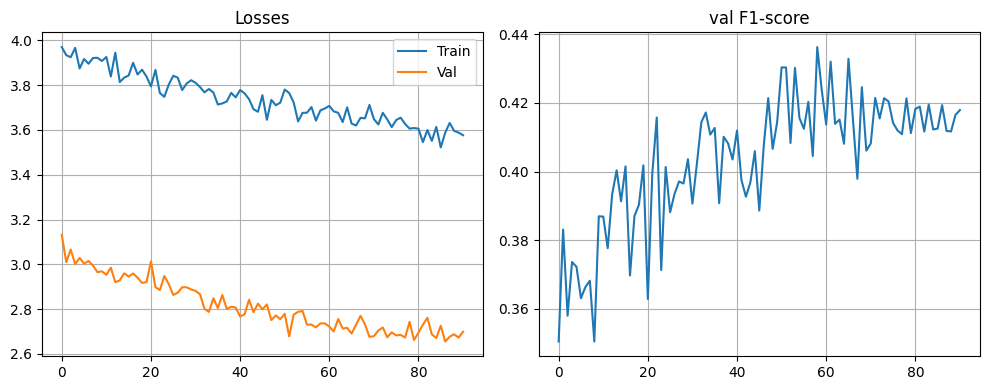

 92%|█████████▏| 92/100 [14:24<01:14,  9.33s/it]

Epoch 91: train_loss 3.651380785580339, val_loss 2.660900299365704, val_f1 0.4201821290838808


 93%|█████████▎| 93/100 [14:33<01:05,  9.33s/it]

Epoch 92: train_loss 3.6238530422079154, val_loss 2.6231636084043064, val_f1 0.4260406833787207


 94%|█████████▍| 94/100 [14:42<00:55,  9.32s/it]

Epoch 93: train_loss 3.592406823717315, val_loss 2.65547880759606, val_f1 0.409088167728191


 95%|█████████▌| 95/100 [14:52<00:47,  9.47s/it]

!!! NEW BEST MODEL !!!
Epoch 94: train_loss 3.567229484689647, val_loss 2.638559964986948, val_f1 0.4408856289821139


 96%|█████████▌| 96/100 [15:01<00:37,  9.43s/it]

Epoch 95: train_loss 3.5751450719504523, val_loss 2.634198408860427, val_f1 0.4241656257197796


 97%|█████████▋| 97/100 [15:11<00:28,  9.53s/it]

!!! NEW BEST MODEL !!!
Epoch 96: train_loss 3.5684118106447418, val_loss 2.5997054760272684, val_f1 0.4459493811030855


 98%|█████████▊| 98/100 [15:21<00:18,  9.47s/it]

Epoch 97: train_loss 3.5085472978394607, val_loss 2.6464482087355394, val_f1 0.44515726560492075


 99%|█████████▉| 99/100 [15:30<00:09,  9.43s/it]

Epoch 98: train_loss 3.549638402873072, val_loss 2.642648458480835, val_f1 0.4421856134805543
Epoch 99: train_loss 3.5749449154426314, val_loss 2.5838612593137302, val_f1 0.42414684863925295


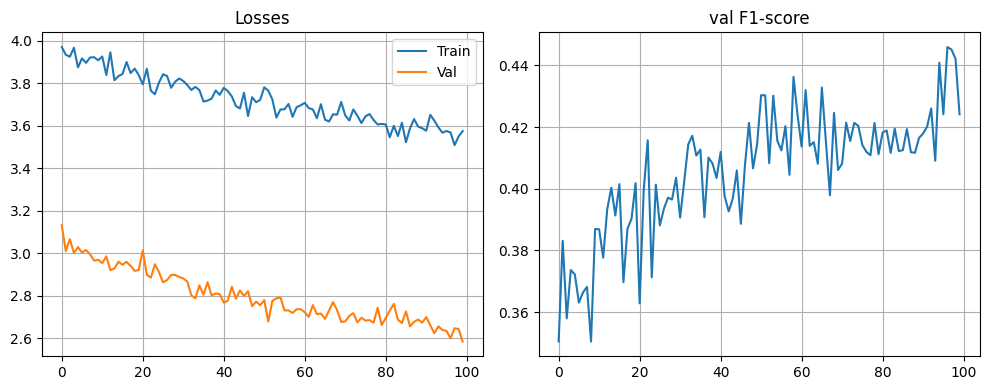

100%|██████████| 100/100 [15:39<00:00,  9.40s/it]

Best score: 0.4459493811030855


PockemonModel(
  (conv_net): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout2d(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout2d(p=0.2, inplace=False)
    (13): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Dropout2d(p=0.2, 

In [ ]:
# model = ic(PockemonModel(
#     img_shape=(224, 224),
#     in_ch=3,
#     hidden_ch=[32, 64, 128],
#     hidden_fc=[512, 256, 128],
#     out_dim=150
# ))

# model.load_state_dict(torch.load('./models/best_model_001.pth'))

# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
# criterion = nn.CrossEntropyLoss()

# train_loop(
#     model=model,
#     train_loader=train_dataloader,
#     val_loader=val_dataloader,
#     optimizer=optimizer,
#     criterion=criterion,
#     model_name="best_model_002.pth"
# )


## Inference

In [ ]:
model = ic(PockemonModel(
    img_shape=(224, 224),
    in_ch=3,
    hidden_ch=[32, 64, 128],
    hidden_fc=[512, 256, 128],
    out_dim=150
))
model.load_state_dict(torch.load('./models/best_model_002.pth'))

ic| PockemonModel(
        img_shape=(224, 224),
        in_ch=3,
        hidden_ch=[32, 64, 128],
        hidden_fc=[512, 256, 128],
        out_dim=150
    ): PockemonModel(
         (conv_net): Sequential(
           (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (2): ReLU()
           (3): Dropout2d(p=0.2, inplace=False)
           (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (6): ReLU()
           (7): Dropout2d(p=0.2, inplace=False)
           (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
           (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
           (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
           (11): ReLU()


<All keys matched successfully>

In [ ]:
df_ss = pd.read_csv("./data/sample_submission.csv")
df_ss.head()

,id,label
0,9553b359,Pikachu
1,c6bcf2c2,Pikachu
2,5493d25f,Pikachu
3,f17f13b5,Pikachu
4,bb4e5386,Pikachu


In [ ]:
test_dataset[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1008,  ..., -1.4672, -1.4672, -2.1179],
          [-2.1179, -2.1179, -2.1008,  ..., -1.4500, -1.4158, -2.1179],
          [-2.1179, -2.1179, -2.0837,  ..., -1.3644, -1.3644, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -2.0007, -2.0357],
          ...,
          [-2.0357, -2.0007, -1.9307,  ..., -0.6877, -0.7752, -1.9307],
          [-2.0182, -1.9832, -1.9482,  ..., -0.6702, -0.7227, -1.9482],
          [-2.0182, -1.9832, -1.9307,  ..., -0.5826, -0.6702, -1.9482]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.5256, -1.5604, -1.6127],
          [-1.8044, -1.8044,

In [ ]:
pred_dict = dict()

model.eval()
with torch.no_grad():
    for i in trange(len(test_dataset)):
        X, y = test_dataset[i]
        X = X.unsqueeze(0)
        id = test_dataset.df.iloc[i]['id']
        pred = model(X).argmax().numpy()
        pred_dict[id] = label_encoder.inverse_transform([pred])[0]

100%|██████████| 1748/1748 [00:28<00:00, 60.63it/s]


{'9553b359': 'Arbok',
 'c6bcf2c2': 'Mankey',
 '5493d25f': 'Fearow',
 'f17f13b5': 'Vaporeon',
 'bb4e5386': 'Jolteon',
 'eb70561f': 'Ivysaur',
 '29e8914c': 'Golduck',
 'fb758c76': 'Nidoking',
 'aa4cc0be': 'Tangela',
 'c91bf142': 'Tentacool',
 '51df204f': 'Poliwag',
 'c192e529': 'Dratini',
 '2c0990e7': 'Magnemite',
 '822aba76': 'Wigglytuff',
 '3be0da63': 'Pidgeot',
 '61899759': 'Nidoking',
 '21f7251f': 'Machoke',
 '14637932': 'Arcanine',
 'aa4894ae': 'Raichu',
 'b689bdcf': 'Wigglytuff',
 'dc906841': 'Ivysaur',
 'd3f0047b': 'Alakazam',
 'f3805681': 'Golduck',
 '05b51fbf': 'Cubone',
 'ac9aa0ba': 'Diglett',
 '7bc21c4d': 'Mewtwo',
 '8713f6de': 'Magnemite',
 '1339ee2a': 'Flareon',
 '29410709': 'Exeggcute',
 '53db180d': 'Poliwrath',
 '416f85e6': 'Staryu',
 '296b993e': 'Machamp',
 '6aa077f0': 'Kingler',
 '96997e40': 'Snorlax',
 'd536f5b7': 'Clefairy',
 '3bdfd063': 'Lapras',
 '88fe7416': 'Marowak',
 'a4868ece': 'Gyarados',
 'ad6a42fe': 'Dratini',
 'dc731aca': 'Horsea',
 '1e7f2e0c': 'Charmeleon',


In [ ]:
df_ss['label'] = df_ss['id'].map(pred_dict)
df_ss.to_csv("./subm.csv", index=False)
df_ss.head()

,id,label
0,9553b359,Arbok
1,c6bcf2c2,Mankey
2,5493d25f,Fearow
3,f17f13b5,Vaporeon
4,bb4e5386,Jolteon
